# Data Analysis Pipeline

ASOS, WU, OpenMesh (CML + PWS). Load or fetch → unified format → maps, plots, CML–PWS matching, rain detection.

## 1. Setup & Imports

Import required libraries and analysis functions for data processing, visualization, and analysis.

In [19]:
import sys
import warnings
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
from analysis.pipeline import (
    get_default_paths,
    load_metadata,
    load_or_fetch_openmesh,
    load_or_fetch_data,
    prepare_analysis_data,
    display_sensors_map,
    display_weather_info,
    adjust_dates,
    plot_cml_rsl,
    filter_cml_links,
)
from analysis.analysis_functions import (
    find_nearest_pws_stations,
    prepare_detection_data,
    run_rolling_std_detection,
    plot_detection_results,
)
from analysis.plotting import (
    plot_weather_params,
    accumulation_plot,
    plot_subnetwork,
)
print("✓ Setup complete")

✓ Setup complete


## 2. Configuration

In [20]:
START_DATE = datetime(2026, 1, 1)
END_DATE   = datetime(2026, 3, 4)
ASOS_STATIONS = ['KLGA', 'KNYC', 'KJFK']
WU_STATIONS = 'all'
MODE = 'fetch'

print("=" * 70)
print("CONFIGURATION")
print("=" * 70)
print(f"Period: {START_DATE.date()} → {END_DATE.date()}")
print(f"Mode: {MODE.upper()}")
print(f"ASOS stations: {ASOS_STATIONS}")
print(f"WU stations: {WU_STATIONS}")
print("=" * 70)

CONFIGURATION
Period: 2026-01-01 → 2026-03-04
Mode: FETCH
ASOS stations: ['KLGA', 'KNYC', 'KJFK']
WU stations: all


## 3. Load Metadata

In [21]:
paths    = get_default_paths()
metadata = load_metadata(paths)

mesonet_meta_path = paths['meta'] / 'mesonet_metadata.csv'
mesonet_meta = pd.read_csv(mesonet_meta_path) if mesonet_meta_path.exists() else None

print("\nMetadata loaded:")
print(f"  ASOS: {len(metadata['asos'])} stations")
print(f"  WU: {len(metadata['wu'])} stations")
print(f"  OpenMesh Links: {len(metadata['openmesh_links'])} sublinks")
if mesonet_meta is not None:
    print(f"  Mesonet: {len(mesonet_meta)} stations")

# Load the fetched mesh metadata (converted to links format)
fetched_links_meta = pd.read_csv(paths['meta'] / 'fetched' / 'links_metadata_output.csv')
print(f"\nFetched links metadata: {len(fetched_links_meta)} sublinks, "
      f"{fetched_links_meta['cml_id'].nunique()} CMLs")

# Load Mesonet station metadata
mesonet_metadata_path = paths['meta'] / 'mesonet_metadata.csv'
if mesonet_metadata_path.exists():
    mesonet_metadata = pd.read_csv(mesonet_metadata_path)
    print(f"Mesonet metadata loaded: {len(mesonet_metadata)} stations")
else:
    mesonet_metadata = None
    print("Mesonet metadata file not found.")



LOADING METADATA
✓ ASOS: 3 stations (ASOS_stations.csv)
✓ WU: 37 stations (pws_metadata.csv)
✓ OpenMesh Links: 103 sublinks (links_metadata.csv)

Metadata loaded:
  ASOS: 3 stations
  WU: 37 stations
  OpenMesh Links: 103 sublinks
  Mesonet: 4 stations

Fetched links metadata: 157 sublinks, 140 CMLs
Mesonet metadata loaded: 4 stations


## 4. Load/Fetch OpenMesh Data (CML & PWS)

`MODE`: load from files or fetch from Zenodo. `PWS_OPENMESH_SOURCE`: sample (Jan sample) or full (`pws_wu_os.nc`).

In [22]:
OPENMESH_MODE = 'load'        # 'fetch' or 'load'
PWS_OPENMESH_SOURCE = 'sample'   # 'sample' or 'full'

ds_links, links_meta, pws_data = load_or_fetch_openmesh(
    paths=paths, mode=OPENMESH_MODE, pws_source=PWS_OPENMESH_SOURCE
)




OPENMESH DATA
Mode: load
  Links: ds_openmesh.nc
  PWS (sample): pws_opensense_sample_jan.nc
✓ Links: 75 | PWS: 37 stations


## 5. Load/Fetch Weather Data (ASOS & WU)

In [23]:
# Load or fetch ASOS and WU data.
WEATHER_DATA_MODE = 'load'


weather_data = load_or_fetch_data(
    mode            = WEATHER_DATA_MODE,
    start_date      = START_DATE,
    end_date        = END_DATE,
    asos_stations   = ASOS_STATIONS,
    wu_stations     = WU_STATIONS if WU_STATIONS != 'all' else None,
    asos_metadata   = metadata['asos'],
    wu_metadata     = metadata['wu'],
)



DATA ACQUISITION: LOAD
Period: 2026-01-01 → 2026-03-04

📁 ASOS
  Folder: /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/raw/fetched/asos
  Available files (8):
    - standard_2023-11-01_2023-11-29.csv
    - standard_2024-01-01_2024-01-29.csv
    - standard_2024-01-01_2024-01-30.csv
    ... +5 more
  ✓ Exact match: standard_2026-01-01_2026-03-04.csv

📁 WU
  Folder: /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/raw/fetched/wu
Found 3 WU file(s)
----------------------------------------------------------------------
Loading: WU_2024-01-01_2024-01-30.csv... ✓ 37 stations, 24,717 total rows
Loading: WU_2024-06-01_2024-06-30.csv... ✓ 36 stations, 25,219 total rows
Loading: WU_2026-01-01_2026-03-04.csv... ✓ 32 stations, 44,688 total rows

✓ Selected: 2026-01-01_2026-03-04 (exact match)
  Stations: ['KNYNEWYO1024', 'KNYNEWYO1053', 'KNYNEWYO1120', 'KNYNEWYO1127', 'KNYNEWYO1238']...
  ✓ File: WU_2026-01-01_2026-03-04.csv

✓ ASOS: 3 stations
✓ WU: 32 stations


In [24]:
from fetch_data.noaa_asos.asos_fetch import save_data as save_station_data
SAVE_FETCHED_DATA = True

if SAVE_FETCHED_DATA and WEATHER_DATA_MODE == 'fetch':

    if weather_data['asos']:
        save_station_data(weather_data['asos'], paths['asos'], prefix='standard',
                          start_date=START_DATE, end_date=END_DATE,
                          save_individual=False, save_combined=True)
    if weather_data['wu']:
        save_station_data(weather_data['wu'], paths['wu'], prefix='wu',
                          start_date=START_DATE, end_date=END_DATE,
                          save_individual=False, save_combined=True)


## 6. Prepare Analysis Data

Combine all data sources into unified format:
- **ASOS**: Airport weather stations
- **WU**: Weather Underground PWS
- **OpenMesh**: CML links + PWS

`PWS_SOURCE`: which PWS to use — `'openmesh'` (Zenodo) or `'wu'` (API)


In [25]:

PWS_SOURCE = 'wu' # 'wu' for fetched data from WU API


datasets = {
    'asos': {
        'raw': weather_data['asos'],
        'meta': metadata['asos']
    },
    'wu': {
        'raw': weather_data['wu'],
        'meta': metadata['wu']
    },
    'openmesh': {
        'raw': {'links': ds_links, 'pws': pws_data},
        'meta': {'links': links_meta, 'pws': metadata['wu']}  # PWS meta same as WU
    }
}

analysis_data = prepare_analysis_data(
    datasets=datasets,
    analysis_period=(START_DATE, END_DATE),
    pws_source='wu',
    parameters='all',
)

print("\n✓ Analysis data prepared")

Preparing Analysis Data (Source: wu)
Period: 2026-01-01 to 2026-03-04
ASOS Params: wind_gust (3), rainfall_rate (3), precip_category (3), wind_speed (3), wind_direction (3), precip_type (3), temperature (3), dewpoint (3), rainfall_amount (3)
PWS Params:  solar_radiation (32), dewpoint (32), wind_chill_high (32), humidity (32), wind_gust_high (32), uv_index_high (32), wind_direction (32), heat_index_high (32), wind_gust (32), rainfall_rate (32), heat_index_low (32), pressure (32), wind_speed (32), rainfall_amount (32), longitude (32), heat_index (32), timestamp_unix (32), timezone (32), temperature (32), time_local (32), qc_status (32), wind_chill_low (32), wind_gust_low (32), wind_chill (32), latitude (32)
Skipping resampling.

✓ Analysis data prepared


In [26]:
# datasets['wu']['raw']
# datasets['openmesh']['raw']['pws']
analysis_data['pws']['rainfall_amount']
# analysis_data['asos']['rainfall_amount']


,KNYNEWYO1024,KNYNEWYO1053,KNYNEWYO1120,KNYNEWYO1127,KNYNEWYO1238,KNYNEWYO1288,KNYNEWYO1298,KNYNEWYO1313,KNYNEWYO1326,KNYNEWYO1388,...,KNYNEWYO1805,KNYNEWYO1824,KNYNEWYO1896,KNYNEWYO1918,KNYNEWYO1921,KNYNEWYO1931,KNYNEWYO1943,KNYNEWYO505,KNYNEWYO589,KNYNEWYO638
datetime,,,,,,,,,,,,,,,,,,,,,
2026-01-01 05:45:06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.00
2026-01-01 05:45:18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.00
2026-01-01 05:45:49,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.00
2026-01-01 05:55:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.00
2026-01-01 05:55:18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-03 23:59:54,0.0,0.0,0.3,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.00
2026-03-03 23:59:55,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.0,0.28,0.0,0.0,0.0,0.00,0.00,0.0,0.00
2026-03-03 23:59:56,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.25,0.0,0.00


## 7. Map Sensors

In [27]:
# Hot-reload analysis.py changes without restarting kernel
import importlib
import pipeline
importlib.reload(pipeline)
from pipeline import *
print("✅ analysis module reloaded")

✅ analysis module reloaded


✓ Filtered to 2 ASOS stations
✓ Filtered to 3 Mesonet stations
✓ Map created
✓ Filtered to 2 ASOS stations
✓ Filtered to 3 Mesonet stations
✓ Map created


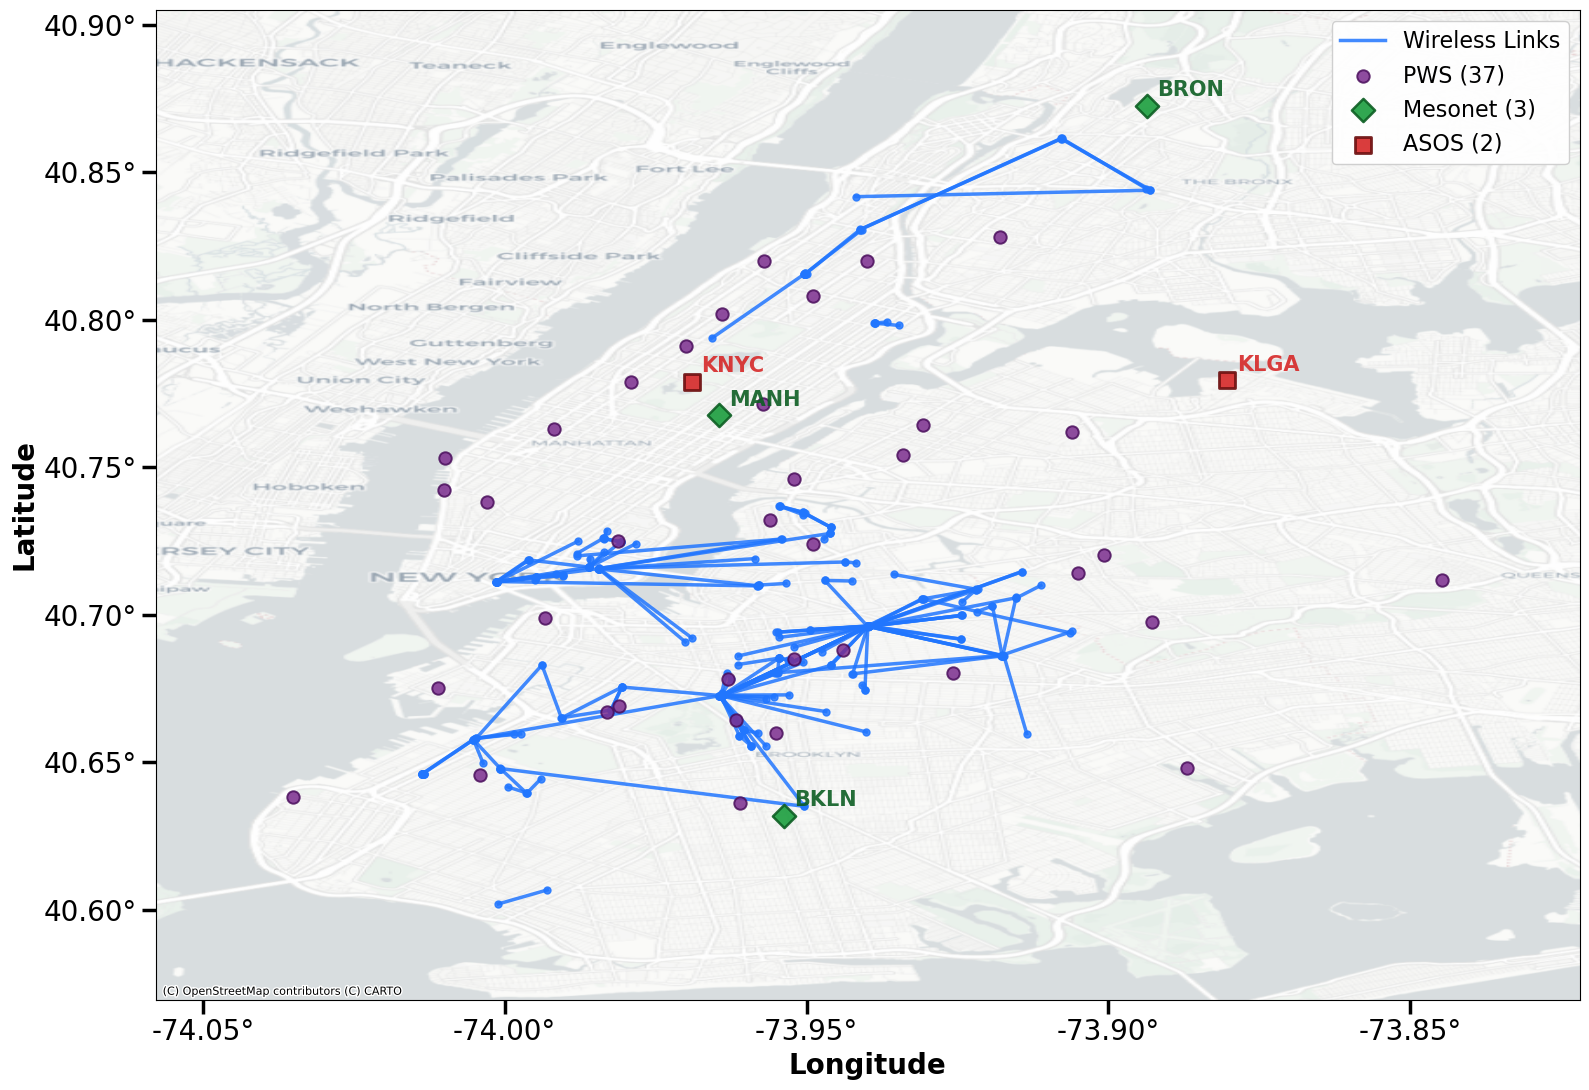

In [48]:

# Original links metadata (from Zenodo)

fig, ax = display_sensors_map(
    links_meta   =fetched_links_meta,
    asos_meta    =metadata['asos'],
    pws_meta            =metadata['wu'],
    mesonet_meta        =mesonet_meta,
    map_type            ='matplotlib',
    show_link_labels    = False,
    show_pws_labels     = False,
    asos_station_ids    = ['KLGA', 'KNYC'],    
    mesonet_station_ids = ['MANH' , 'BKLN', 'BRON']
)


m = display_sensors_map(
    links_meta          =fetched_links_meta,
    asos_meta           =metadata['asos'],
    pws_meta            =metadata['wu'],
    mesonet_meta        =mesonet_meta,
    map_type            ='folium',
    show_link_labels    =False,
    show_pws_labels     =False,
    asos_station_ids    =['KLGA', 'KNYC'],    
    mesonet_station_ids =['MANH', 'BKLN', 'BRON']
)

# fig, ax = display_sensors_map(
#     links_meta   =metadata['openmesh_links'],
#     asos_meta    =metadata['asos'],
#     pws_meta     =metadata['wu'],
#     mesonet_meta =mesonet_meta,
#     map_type     ='matplotlib',
#     show_link_labels=True,
#     asos_station_ids=['KLGA', 'KNYC'],
# )


# Fetched mesh links metadata (from API → meta_convertor).

# fig, ax = display_sensors_map(
#     links_meta   =fetched_links_meta,
#     asos_meta    =metadata['asos'],
#     pws_meta     =metadata['wu'],
#     mesonet_meta =mesonet_meta,
#     map_type     ='matplotlib',
#     show_link_labels=False,
#     show_pws_labels=False,
#     asos_station_ids=['KLGA', 'KNYC'],    
#     mesonet_station_ids= ['MANH' , 'BKLN']
# )



In [49]:
m.save('map.html')

## 8. Display Weather Data

In [29]:
display_weather_info()

adjust_dates_flag = True

if adjust_dates_flag:
    original_start = START_DATE
    original_end = END_DATE
    
    START_DATE, END_DATE = adjust_dates(analysis_data, START_DATE, END_DATE)
    
    print(f"\n📅 Date Range Adjustment:")
    print(f"  Original: {original_start.date()} → {original_end.date()}")
    print(f"  Adjusted: {START_DATE.date()} → {END_DATE.date()}")
    print("=" * 70)


DISPLAY WEATHER
### Display Precipitation :

📅 Date Range Adjustment:
  Original: 2026-01-01 → 2026-03-04
  Adjusted: 2026-01-01 → 2026-03-03


  ℹ Showing first 10 of 32 PWS stations
  ℹ Showing first 10 of 32 PWS stations


(<Figure size 1600x800 with 2 Axes>,
 array([<Axes: title={'center': 'ASOS - Rainfall Amount (mm) (3 stations)'}, ylabel='Rainfall Amount (mm)'>,
        <Axes: title={'center': 'PWS - Rainfall Amount (mm) (10/32 stations)'}, xlabel='Time', ylabel='Rainfall Amount (mm)'>],
       dtype=object))

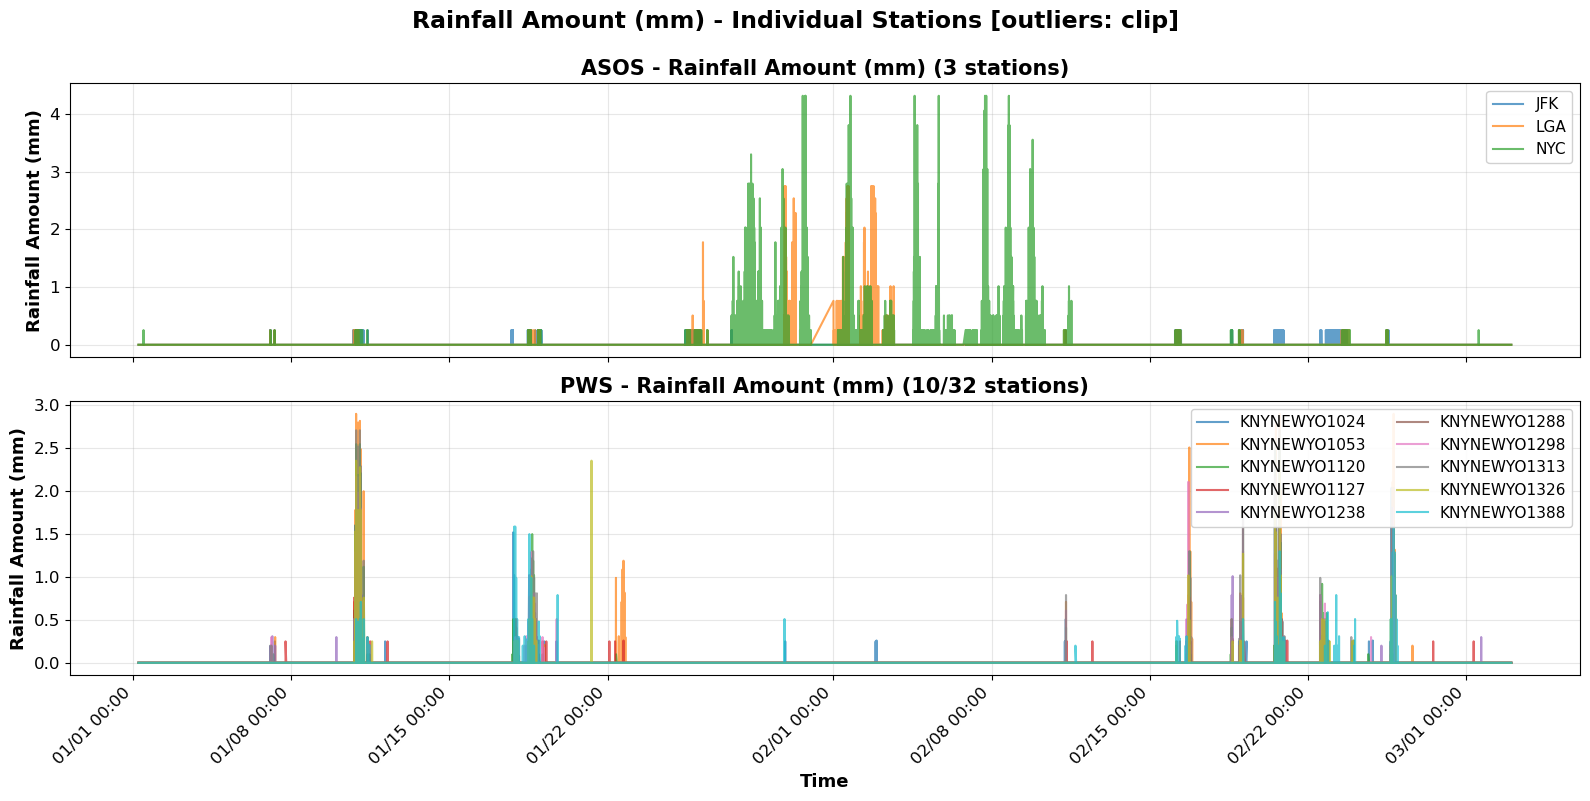

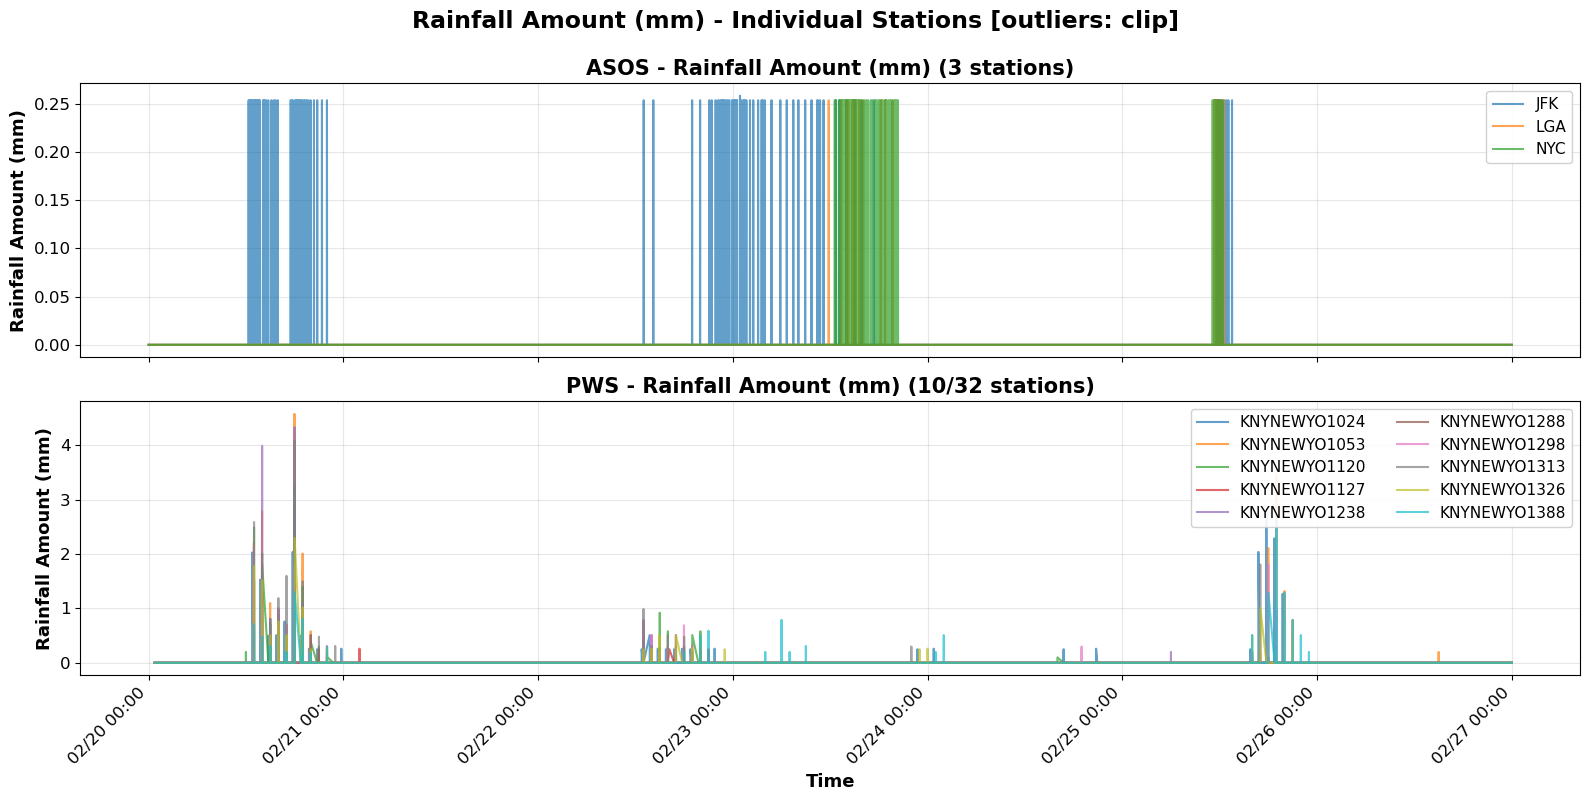

In [ ]:
plot_weather_params(
    analysis_data,
    parameter='rainfall_amount',
    mode='raw',
    max_stations=10,
    start_date=START_DATE,
    end_date=END_DATE,
)

plot_weather_params(
    analysis_data,
    parameter='rainfall_amount',
    mode='raw',
    
    # max_stations=10,
    start_date  = '2026-02-20',
    end_date    = '2026-02-27',
)
# plot_weather_params(
#     analysis_data,
#     parameter='rainfall_amount',
#     mode='overlay',
#     ylim=1,
#     start_date=START_DATE,
#     end_date=END_DATE,
# )
# plot_weather_params(
#     analysis_data,
#     parameter='temperature',
#     start_date=START_DATE,
#     end_date=END_DATE,
#     mode='stats',
# )




In [ ]:
def classify_precipitation(df_precip, 
                           stations=None, 
                           method='priority', 
                           priority_list=['ice', 'snow', 'mix', 'rain'], 
                           threshold=0.05, 
                           resample_rate='15min'):
    if stations is not None:
        valid_stations = [s for s in stations if s in df_precip.columns]
        if not valid_stations:
            return pd.Series(dtype=str)
        df_filtered = df_precip[valid_stations]
    else:
        df_filtered = df_precip.copy()

    if df_filtered.empty:
        return pd.Series(dtype=str)

    def get_consensus(window):
        # window is a DataFrame chunk from resample — flatten all values
        if hasattr(window, 'values'):
            vals = window.values.flatten()
        else:
            vals = np.array(window).flatten()
            
        vals = vals[pd.notna(vals)]
        vals = vals[vals != '']
        
        if len(vals) == 0:
            return 'dry'
            
        counts = pd.Series(vals).value_counts(normalize=True)
        
        if method == 'priority':
            for p_type in priority_list:
                if p_type in counts and counts[p_type] >= threshold:
                    return p_type
            return counts.index[0]
            
        elif method == 'normal':
            return counts.index[0]

        return 'dry'

    # Resample each column separately, then combine and apply consensus per row
    resampled = df_filtered.resample(resample_rate).agg(
        lambda x: x.mode()[0] if len(x) > 0 and x.notna().any() else 'dry'
    )
    
    # Now apply consensus across columns (axis=1)
    def row_consensus(row):
        vals = row.values
        vals = vals[pd.notna(vals)]
        vals = vals[vals != 'dry']  # treat dry as absence
        
        if len(vals) == 0:
            return 'dry'
        
        counts = pd.Series(vals).value_counts(normalize=True)
        
        if method == 'priority':
            for p_type in priority_list:
                if p_type in counts and counts[p_type] >= threshold:
                    return p_type
            return counts.index[0]
        elif method == 'normal':
            return counts.index[0]
        
        return 'dry'
    
    return resampled.apply(row_consensus, axis=1)

In [88]:
# ── Font / tick size config ──────────────────────────────────────────
PLOT_CFG = dict(
    figsize              = (16, 8),
    title_size           = 18,
    axis_label_size      = 15,
    tick_size            = 13,
    legend_size          = 11,
    xtick_rotation       = 45,
    ylim_percentile_asos = 95,
    ylim_percentile_pws  = 95,
)
# ────────────────────────────────────────────────────────────────────

def accumulation_plot(analysis_data,
                     date_range=None,
                     datasets='both',
                     asos_stations=None,
                     pws_stations=None,
                     stats=False,
                     show_precip_grid=False,
                     cfg=PLOT_CFG):

    color_map = {
        'dry':  'lightgray',
        'rain': '#4A90D9',
        'snow': '#A8D8EA',
        'ice':  '#FF6B35',
        'mix':  '#9E9E9E'
    }

    start_date, end_date = date_range if date_range else (None, None)
    fig, ax = plt.subplots(figsize=cfg['figsize'])

    asos_maxes = []
    pws_maxes  = []

    # ── ASOS ────────────────────────────────────────────────────────
    df_asos = None
    if datasets in ['both', 'asos'] and 'rainfall_amount' in analysis_data.get('asos', {}):
        df_asos = analysis_data['asos']['rainfall_amount'].copy()
        if date_range:
            df_asos = df_asos[(df_asos.index >= start_date) & (df_asos.index <= end_date)]
        if asos_stations is not None:
            avail = [s for s in asos_stations if s in df_asos.columns]
            df_asos = df_asos[avail] if avail else None

    # ── PWS ─────────────────────────────────────────────────────────
    df_pws = None
    if datasets in ['both', 'pws'] and 'rainfall_amount' in analysis_data.get('pws', {}):
        df_pws = analysis_data['pws']['rainfall_amount'].copy()
        if date_range:
            df_pws = df_pws[(df_pws.index >= start_date) & (df_pws.index <= end_date)]
        if pws_stations is not None:
            avail = [s for s in pws_stations if s in df_pws.columns]
            df_pws = df_pws[avail] if avail else None

    # ── Precip background ───────────────────────────────────────────
    if show_precip_grid and 'precip_type' in analysis_data.get('asos', {}):
        df_precip = analysis_data['asos']['precip_type'].copy()
        if date_range:
            df_precip = df_precip[(df_precip.index >= start_date) & (df_precip.index <= end_date)]
        if not df_precip.empty:
            consensus = classify_precipitation(df_precip, stations=asos_stations)
            for ptype, periods in get_precip_spans(consensus).items():
                color = color_map.get(ptype, 'lightgray')
                for i, (ps, pe) in enumerate(periods):
                    ax.axvspan(ps, pe, alpha=0.8, color=color, zorder=0,
                               edgecolor='none',
                               label=ptype.capitalize() if i == 0 else None)

    # ── Plot ASOS ───────────────────────────────────────────────────
    colors_asos = plt.cm.tab10(np.linspace(0, 1, 10))
    if df_asos is not None and len(df_asos.columns) > 0:
        for idx, col in enumerate(df_asos.columns):
            cs = df_asos[col].fillna(0).cumsum()
            asos_maxes.append(cs.max())
            ax.plot(cs.index, cs.values,
                    color=colors_asos[idx % len(colors_asos)],
                    label=f'ASOS {col}', linewidth=2.5, zorder=5)

    # ── Plot PWS individual lines ────────────────────────────────────
    colors_pws    = plt.cm.Pastel1(np.linspace(0, 1, 9))
    single_legend = (pws_stations is None)

    if df_pws is not None and len(df_pws.columns) > 0:
        for idx, col in enumerate(df_pws.columns):
            cs = df_pws[col].fillna(0).cumsum()
            pws_maxes.append(cs.max())
            ax.plot(cs.index, cs.values,
                    color='steelblue' if single_legend else colors_pws[idx % len(colors_pws)],
                    label='PWS stations' if (single_legend and idx == 0) else (None if single_legend else f'PWS {col}'),
                    linewidth=1.2, alpha=0.8, zorder=4)

        # ── PWS average (always shown, bold black) ───────────────────
        pws_avg = df_pws.mean(axis=1).fillna(0).cumsum()
        pws_maxes.append(pws_avg.max())
        ax.plot(pws_avg.index, pws_avg.values,
                color='black', linewidth=2.8, linestyle='-',
                label='PWS Avg', alpha=0.9, zorder=7)

        if stats:
            pws_med = df_pws.median(axis=1).fillna(0).cumsum()
            pws_maxes.append(pws_med.max())
            ax.plot(pws_med.index, pws_med.values,
                    color='dimgray', linewidth=2.2, linestyle='--',
                    label='PWS Median', alpha=0.85, zorder=6)

    # ── Y-limit ──────────────────────────────────────────────────────
    def calc_ylim(maxes, percentile):
        valid = [v for v in maxes if pd.notna(v) and v > 0]
        if not valid:
            return None
        if percentile == 'max' or percentile >= 100:
            return max(valid)
        y = np.percentile(valid, percentile)
        if len(valid) > 1:
            y = max(y, sorted(valid)[-2])
        return y

    y_asos     = calc_ylim(asos_maxes, cfg['ylim_percentile_asos'])
    y_pws      = calc_ylim(pws_maxes,  cfg['ylim_percentile_pws'])
    candidates = [v for v in [y_asos, y_pws] if v is not None]
    if candidates:
        ax.set_ylim(0, max(candidates) * 1.05)

    # ── Formatting ───────────────────────────────────────────────────
    ax.set_xlabel('Time',                          fontsize=cfg['axis_label_size'], fontweight='bold')
    ax.set_ylabel('Cumulative Precipitation (mm)', fontsize=cfg['axis_label_size'], fontweight='bold')
    ax.set_title('Precipitation Accumulation',     fontsize=cfg['title_size'],      fontweight='bold')
    ax.grid(True, alpha=0.4, zorder=1)
    ax.tick_params(labelsize=cfg['tick_size'])

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax.xaxis.get_majorticklabels(),
             rotation=cfg['xtick_rotation'], ha='right', fontsize=cfg['tick_size'])

    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
              fontsize=cfg['legend_size'], framealpha=0.9)

    plt.tight_layout()
    return fig, ax

In [ ]:
import pandas as pd

data = [
    ("1:51 AM",  1,  0, 92, "NE",  17,  0, 1018.92, 0.0, "Mostly Cloudy"),
    ("2:51 AM",  1,  0, 92, "NE",  17,  0, 1018.92, 0.0, "Mostly Cloudy"),
    ("3:17 AM",  1,  0, 92, "NE",  15,  0, 1018.58, 0.0, "Mist"),
    ("3:47 AM",  1,  0, 93, "ENE", 13,  0, 1018.92, 0.0, "Mist"),
    ("3:51 AM",  1,  0, 92, "ENE", 13,  0, 1018.92, 0.0, "Mist"),
    ("4:51 AM",  1,  0, 92, "NE",  15,  0, 1017.90, 0.0, "Mist"),
    ("5:51 AM",  1,  0, 92, "NNE", 17,  0, 1018.24, 0.0, "Mist"),
    ("6:04 AM",  1,  0, 92, "NE",  22,  0, 1017.90, 0.0, "Mist"),
    ("6:58 AM",  1,  0, 93, "NE",  19,  0, 1018.24, 0.0, "Mist"),
    ("7:00 AM",  1,  0, 96, "NE",  20,  0, 1018.24, 0.0, "Mist"),
    ("7:51 AM",  1,  0, 92, "NE",  19,  0, 1018.24, 0.0, "Light Rain"),
    ("8:23 AM",  1,  0, 92, "NE",  22,  0, 1018.58, 0.3, "Wintry Mix"),
    ("8:51 AM",  1,  0, 96, "NE",  19,  0, 1018.58, 0.5, "Wintry Mix"),
    ("8:58 AM",  1,  0, 96, "NE",  20,  0, 1018.58, 0.3, "Light Snow"),
    ("9:51 AM",  1, -1, 92, "NE",  20,  0, 1017.90, 0.8, "Light Snow"),
    ("10:05 AM", 0, -1, 96, "NE",  20,  0, 1017.90, 0.0, "Light Snow"),
    ("10:51 AM", 0, -1, 92, "NE",  26,  0, 1017.56, 0.5, "Light Snow"),
    ("11:51 AM", 0, -1, 92, "NE",  22,  0, 1016.89, 0.0, "Light Snow"),
    ("12:51 PM", 0, -1, 92, "NE",  28,  0, 1016.89, 0.3, "Light Snow"),
    ("1:51 PM",  0, -1, 92, "NE",  26, 43, 1015.87, 0.3, "Light Snow"),
    ("2:23 PM",  0, -1, 92, "NE",  30,  0, 1015.19, 0.0, "Light Snow"),
    ("2:51 PM",  0, -1, 92, "NE",  33,  0, 1015.53, 0.0, "Light Snow / Windy"),
    ("3:07 PM",  0, -1, 92, "NE",  31,  0, 1015.19, 0.0, "Light Snow"),
    ("3:51 PM",  0, -1, 92, "NE",  35,  0, 1013.84, 0.3, "Light Snow / Windy"),
    ("4:07 PM",  0, -1, 92, "NE",  43,  0, 1013.50, 0.0, "Light Snow / Windy"),
    ("4:51 PM",  0, -1, 92, "ENE", 37, 52, 1012.82, 0.0, "Light Snow / Windy"),
    ("5:51 PM", -1, -2, 92, "NE",  39, 56, 1012.49, 0.3, "Light Snow / Windy"),
    ("6:14 PM", -1, -1, 96, "NE",  37, 50, 1011.81, 0.3, "Light Snow / Windy"),
    ("6:51 PM", -1, -1, 96, "NE",  39, 52, 1010.79, 0.8, "Light Snow / Windy"),
    ("7:51 PM", -1, -1, 96, "NE",  31, 48, 1011.13, 1.5, "Light Snow"),
    ("8:10 PM", -1, -1, 96, "NE",  31, 48, 1010.79, 0.3, "Fog"),
    ("8:15 PM", -1, -1, 96, "NE",  31, 48, 1010.46, 0.5, "Fog"),
    ("8:51 PM", -1, -1, 96, "NE",  33, 48, 1010.12, 1.8, "Light Snow / Windy"),
    ("9:51 PM", -1, -1, 96, "NNE", 33, 46, 1009.10, 2.0, "Fog / Windy"),
    ("10:51 PM",-1, -1, 96, "N",   35, 48, 1007.07, 1.3, "Fog / Windy"),
    ("11:34 PM",-1, -1, 96, "N",   37, 56, 1005.72, 0.5, "Fog / Windy"),
    ("11:51 PM",-1, -1, 96, "N",   35, 54, 1005.72, 0.8, "Fog / Windy"),
    ("12:51 AM",-1, -1, 96, "N",   41, 61, 1003.35, 0.8, "Fog / Windy"),
]

df = pd.DataFrame(data, columns=[
    'time', 'temp_c', 'dewpoint_c', 'humidity_pct',
    'wind_dir', 'wind_speed_kmh', 'wind_gust_kmh',
    'pressure_hpa', 'precip_mm', 'condition'
])

# specify the date manually
date = '2026--01'
df['datetime'] = pd.to_datetime(date + ' ' + df['time'], format='%Y-%m-%d %I:%M %p')
df = df.drop(columns='time').set_index('datetime')




,JFK,LGA,NYC
datetime,,,
2026-01-01 05:00:00,0.0,0.0,0.0
2026-01-01 05:01:00,0.0,0.0,0.0
2026-01-01 05:02:00,0.0,0.0,0.0
2026-01-01 05:03:00,0.0,0.0,0.0
2026-01-01 05:04:00,0.0,0.0,0.0
...,...,...,...
2026-03-02 23:57:00,0.0,0.0,0.0
2026-03-02 23:58:00,0.0,0.0,0.0
2026-03-02 23:59:00,0.0,0.0,0.0


NameError: name 'df' is not defined

In [31]:
from analysis.helpers import load_pkl

df_6ghz  = load_pkl('data_6GHz.pkl')
df_60ghz = load_pkl('data_60GHz.pkl')

  Saved CSV: data_6GHz.csv (3286 rows)
  Loaded: data_6GHz.pkl → 3286 rows, 2 cols
  Saved CSV: data_60GHz.csv (21 rows)
  Loaded: data_60GHz.pkl → 21 rows, 4 cols


In [32]:
from analysis.helpers import load_experiments

exp_data = load_experiments(date='2026-02-23')

df_6ghz      =  exp_data['6ghz']
df_60ghz_rx1 =  exp_data['60ghz_rx1']
df_60ghz_rx2 =  exp_data['60ghz_rx2']


  Loaded: data_6GHz.pkl → 3286 rows, 2 cols
  Loaded: data_60GHz.pkl → 21 rows, 4 cols
  6ghz         → 3286 rows  |  00:00:19 → 23:59:49
  60ghz_rx1    →   21 rows  |  09:20:00 → 13:36:00
  60ghz_rx2    →   21 rows  |  09:25:00 → 13:27:00


In [33]:
exp_data['60ghz_rx1'].head()

,date,rx_power,time,datetime
0,2026-02-23,-68.412158,09:20:00,2026-02-23 09:20:00
1,2026-02-23,-69.550690,09:30:00,2026-02-23 09:30:00
2,2026-02-23,-69.869181,09:50:00,2026-02-23 09:50:00
3,2026-02-23,-69.692709,09:56:00,2026-02-23 09:56:00
4,2026-02-23,-70.336744,10:02:00,2026-02-23 10:02:00


In [34]:
# Hot-reload analysis.py changes without restarting kernel
import importlib
import helpers
importlib.reload(helpers)
from helpers import *
print("✅ analysis module reloaded")


✅ analysis module reloaded


In [86]:

# from analysis.helpers import find_nearest_stations


exp_wu_stations = find_nearest_stations(
    lat =  40.8075,
    lon = -73.9619,
    meta=metadata['wu'],
    max_distance_km = 3,   # optional: only within 5 km
    max_stations    = 5,     # optional: at most 10 stations
)



  Found 5 stations within 3 km of (40.8075, -73.9619)
  Station ID  Latitude  Longitude  distance_km
KNYNEWYO1622 40.802000 -73.964000     0.636602
KNYNEWYO1238 40.807999 -73.948997     1.087387
KNYNEWYO1942 40.820000 -73.957000     1.449817
KNYNEWYO1931 40.791000 -73.970000     1.957309
KNYNEWYO1472 40.820000 -73.940000     2.308393


<Axes: xlabel='datetime'>

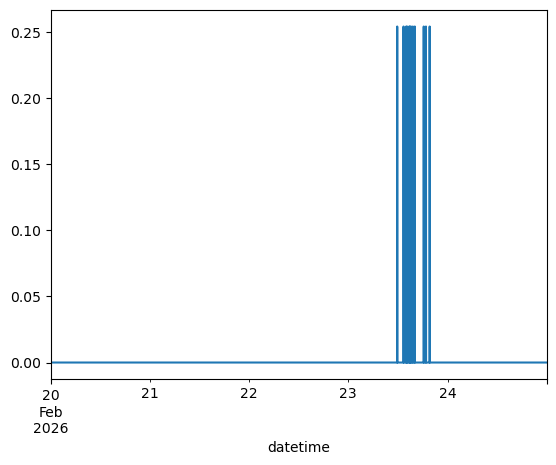

In [93]:
analysis_data['asos']['rainfall_amount']['LGA']['2026-02-20':'2026-02-24'].plot()

  ℹ Showing first 10 of 32 PWS stations


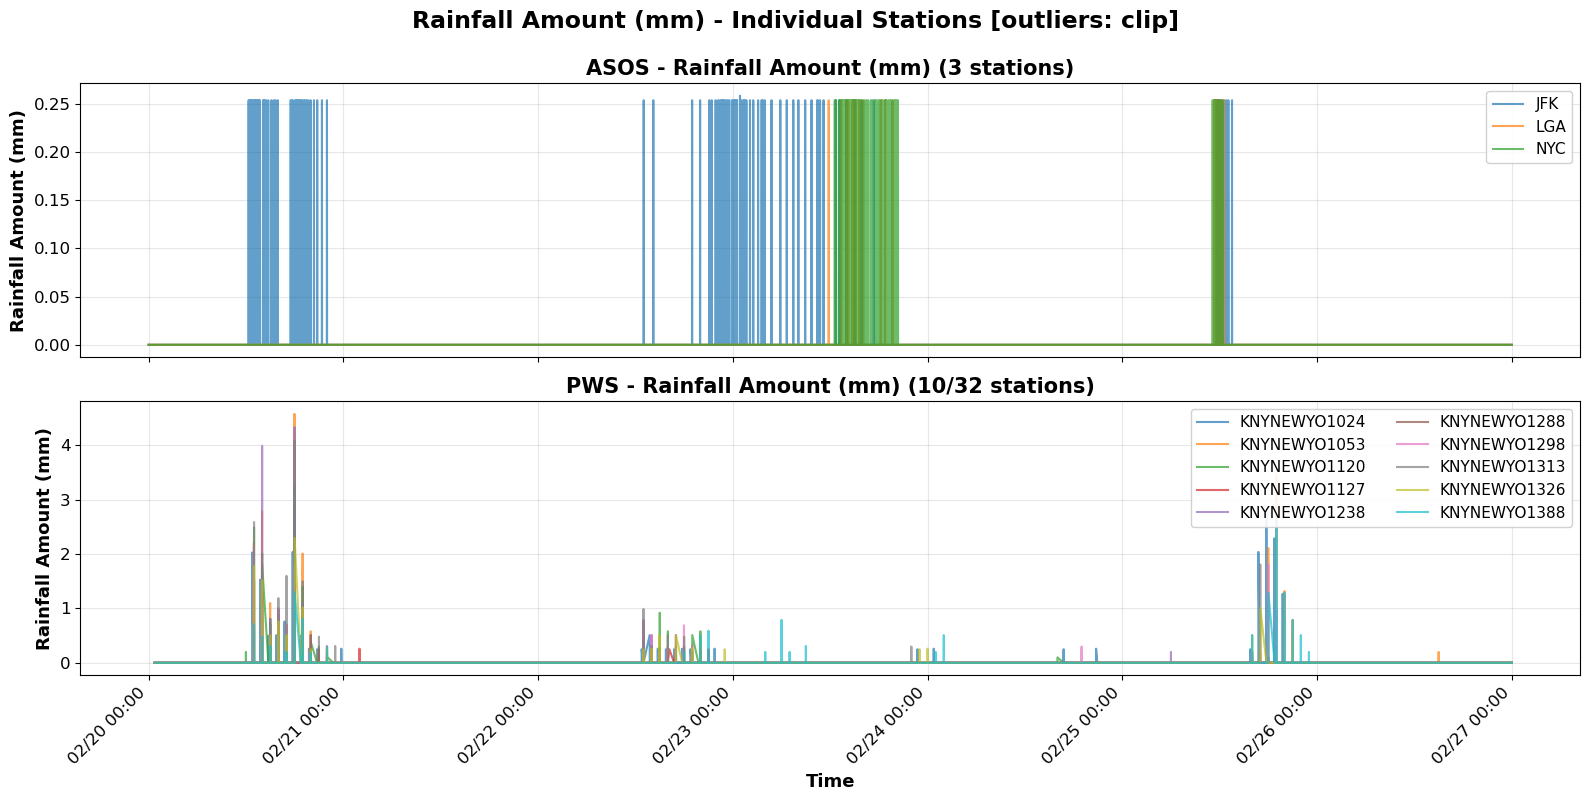

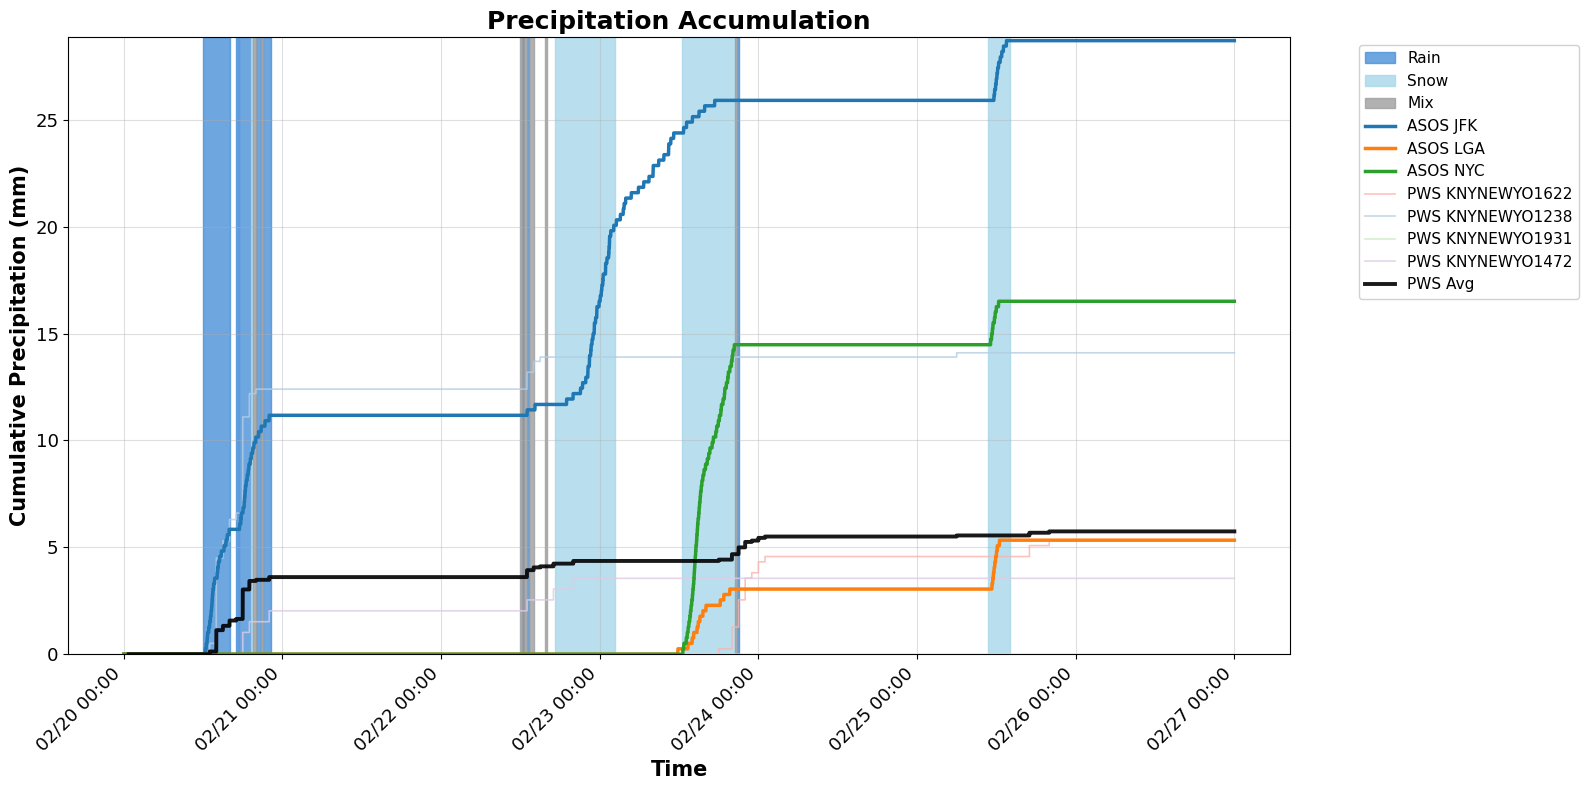

In [89]:
from turtle import st


START_EXP_DATE = '2026-02-20'
END_EXP_DATE   = '2026-02-27'

plot_weather_params(
    analysis_data,
    parameter='rainfall_amount',
    mode='raw',
    # max_stations=10,
    start_date  = START_EXP_DATE ,
    end_date    = END_EXP_DATE
)



fig, ax = accumulation_plot(
    analysis_data,
    date_range=(START_EXP_DATE, END_EXP_DATE),
    show_precip_grid=True,
    pws_stations=exp_wu_stations['Station ID'].values,
    
    
)



In [74]:
exp_wu_stations['Station ID'].values

array(['KNYNEWYO1622', 'KNYNEWYO1238', 'KNYNEWYO1942', 'KNYNEWYO1931',
       'KNYNEWYO1472', 'KNYNEWYO1796', 'KNYNEWYO1024', 'KNYNEWYO1288'],
      dtype=object)

In [67]:
# from analysis.helpers import load_experiments, find_nearest_stations, prepare_experiment_data

# 1. Load experiment data
experiments = load_experiments(date='2026-02-23')

# 2. Find nearby WU stations
exp_wu = find_nearest_stations(40.8075, -73.9619, metadata['wu'], max_distance_km=5)
wu_ids = exp_wu['Station ID'].tolist()

# 3. Build correlated dataset
exp_analysis = prepare_experiment_data(
    experiments=experiments,
    analysis_data=analysis_data,
    pws_station_ids=wu_ids,
    asos_station_ids=['LGA', 'NYC','JFK'],
)

# What you get back:
print("PWS params:", list(exp_analysis['pws'].keys()))
print("ASOS params:", list(exp_analysis['asos'].keys()))

  Loaded: data_6GHz.pkl → 3286 rows, 2 cols
  Loaded: data_60GHz.pkl → 21 rows, 4 cols
  6ghz         → 3286 rows  |  00:00:19 → 23:59:49
  60ghz_rx1    →   21 rows  |  09:20:00 → 13:36:00
  60ghz_rx2    →   21 rows  |  09:25:00 → 13:27:00
  Found 8 stations within 5 km of (40.8075, -73.9619)
  Station ID  Latitude  Longitude  distance_km
KNYNEWYO1622 40.802000 -73.964000     0.636602
KNYNEWYO1238 40.807999 -73.948997     1.087387
KNYNEWYO1942 40.820000 -73.957000     1.449817
KNYNEWYO1931 40.791000 -73.970000     1.957309
KNYNEWYO1472 40.820000 -73.940000     2.308393
Experiment signals: ['6ghz', '60ghz_rx1', '60ghz_rx2']  (00:00–23:59)
analysis_data has: pws=['solar_radiation', 'dewpoint', 'wind_chill_high', 'humidity', 'wind_gust_high', 'uv_index_high', 'wind_direction', 'heat_index_high', 'wind_gust', 'rainfall_rate', 'heat_index_low', 'pressure', 'wind_speed', 'rainfall_amount', 'longitude', 'heat_index', 'timestamp_unix', 'timezone', 'temperature', 'time_local', 'qc_status', 'win

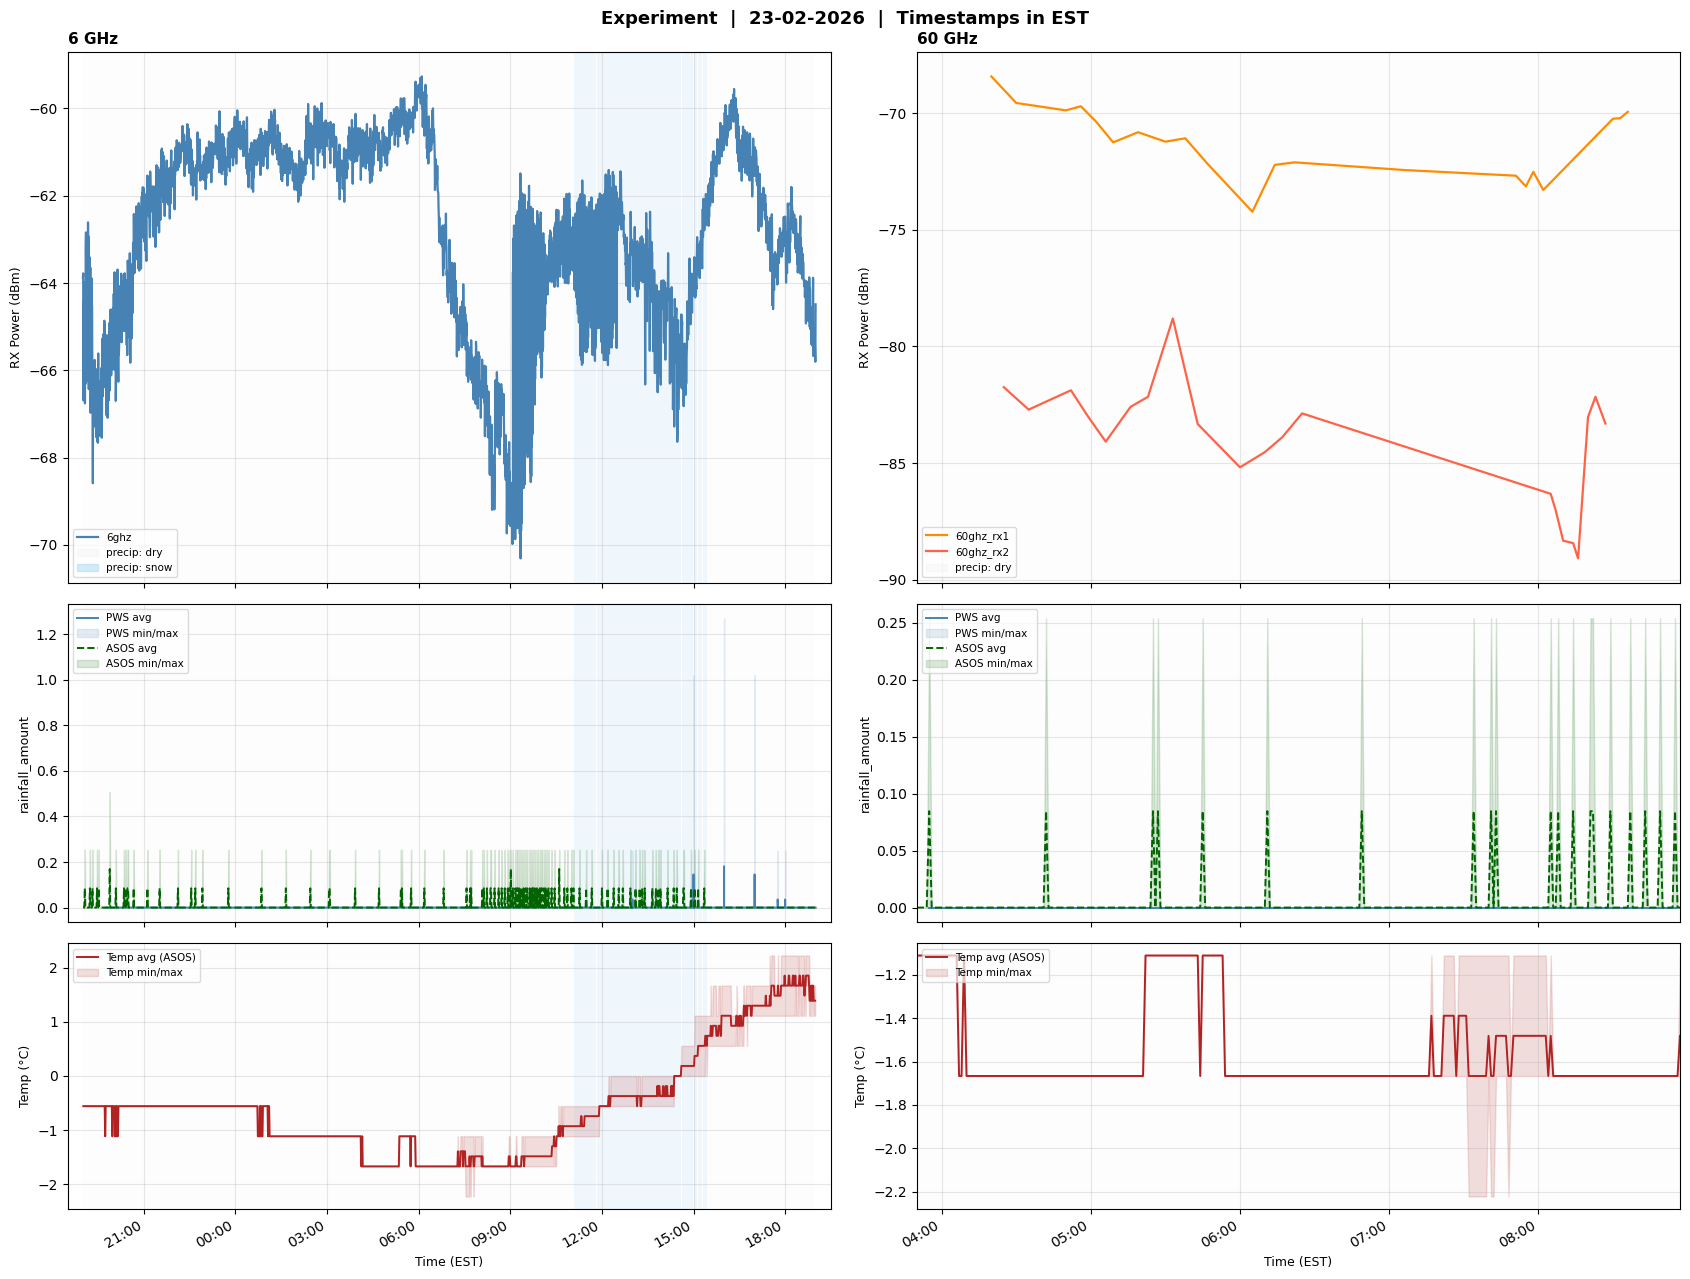

In [38]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# ── constants ─────────────────────────────────────────────────
UTC_OFFSET = pd.Timedelta(hours=-5)  # UTC → EST

PWS_STATIONS = ['KNYNEWYO1024', 'KNYNEWYO1238', 'KNYNEWYO1288',
                'KNYNEWYO1472', 'KNYNEWYO1622', 'KNYNEWYO1796', 'KNYNEWYO1931']
ASOS_STATIONS = ['JFK', 'LGA', 'NYC']

PRECIP_COLORS = {
    'snow':     '#a8d8f0',
    'rain':     '#4a90d9',
    'drizzle':  '#b0d4a0',
    'dry':      '#f5f5f5',
    'unknown':  '#eeeeee',
}

BUFFER = pd.Timedelta(minutes=30)


def to_est(index):
    return index + UTC_OFFSET


def get_precip_color(val):
    if pd.isna(val):
        return PRECIP_COLORS['unknown']
    return PRECIP_COLORS.get(str(val).lower(), PRECIP_COLORS['unknown'])


def plot_full_experiment(exp_analysis,
                         weather_var='rainfall_amount',
                         buffer=BUFFER,
                         figsize=(17, 13)):

    expt   = exp_analysis['experiment']
    pws    = exp_analysis['pws']
    asos   = exp_analysis['asos']

    # ── time window (EST) ────────────────────────────────────
    win_start_utc = min(expt[k].index.min() for k in ['6ghz', '60ghz_rx1', '60ghz_rx2'])
    win_end_utc   = max(expt[k].index.max() for k in ['6ghz', '60ghz_rx1', '60ghz_rx2'])

    # separate windows per experiment
    w6_start  = to_est(expt['6ghz'].index.min()    - buffer)
    w6_end    = to_est(expt['6ghz'].index.max()    + buffer)
    w60_start = to_est(expt['60ghz_rx1'].index.min() - buffer)
    w60_end   = to_est(expt['60ghz_rx1'].index.max() + buffer)

    # ── weather: crop + EST ───────────────────────────────────
    def prep_weather(df, start_utc, end_utc):
        mask = (df.index >= start_utc - buffer) & (df.index <= end_utc + buffer)
        out  = df.loc[mask].copy()
        out.index = to_est(out.index)
        return out

    # ── PWS rainfall ──────────────────────────────────────────
    def pws_stats(start_utc, end_utc):
        df  = prep_weather(pws[weather_var][PWS_STATIONS], start_utc, end_utc)
        avg = df.mean(axis=1)
        mn  = df.min(axis=1)
        mx  = df.max(axis=1)
        return avg, mn, mx

    # ── ASOS rainfall ─────────────────────────────────────────
    def asos_stats(start_utc, end_utc):
        df  = prep_weather(asos[weather_var][ASOS_STATIONS], start_utc, end_utc)
        avg = df.mean(axis=1)
        mn  = df.min(axis=1)
        mx  = df.max(axis=1)
        return avg, mn, mx

    # ── ASOS temperature ──────────────────────────────────────
    def asos_temp(start_utc, end_utc):
        df = prep_weather(asos['temperature'][ASOS_STATIONS], start_utc, end_utc)
        return df.mean(axis=1), df.min(axis=1), df.max(axis=1)

    # ── precip type background ────────────────────────────────
    def draw_precip_bg(ax, start_utc, end_utc, xmin, xmax):
        pt = prep_weather(asos['precip_type'][ASOS_STATIONS], start_utc, end_utc)
        # majority vote per timestamp
        def majority(row):
            vals = row.dropna()
            if vals.empty: return 'unknown'
            return vals.mode()[0]
        dominant = pt.apply(majority, axis=1)

        ymin, ymax = ax.get_ylim()
        prev_t, prev_c = None, None
        for t, ptype in dominant.items():
            color = get_precip_color(ptype)
            if prev_t is not None:
                ax.axvspan(prev_t, t, ymin=0, ymax=1,
                           color=color, alpha=0.18, linewidth=0, zorder=0)
            prev_t, prev_c = t, color
        # legend patches
        seen = dominant.unique()
        patches = [mpatches.Patch(color=get_precip_color(p), alpha=0.5, label=f'precip: {p}')
                   for p in seen]
        return patches

    # ══════════════════════════════════════════════════════════
    # FIGURE LAYOUT:  4 rows × 2 cols
    #   col 0 = 6 GHz window   |   col 1 = 60 GHz window
    #   row 0 = signal
    #   row 1 = rainfall (PWS + ASOS)
    #   row 2 = temperature
    #   row 3 = precip type legend row (thin)
    # ══════════════════════════════════════════════════════════
    fig, axes = plt.subplots(3, 2, figsize=figsize,
                             gridspec_kw={'height_ratios': [2, 1.2, 1]})
    fig.suptitle('Experiment  |  23-02-2026  |  Timestamps in EST',
                 fontsize=13, fontweight='bold')

    col_info = [
        ('6 GHz',  '6ghz',   [('6ghz',  'steelblue', 'solid')],
         expt['6ghz'].index.min(), expt['6ghz'].index.max()),
        ('60 GHz', '60ghz',  [('60ghz_rx1', 'darkorange', 'solid'),
                               ('60ghz_rx2', 'tomato',     'solid')],
         expt['60ghz_rx1'].index.min(), expt['60ghz_rx2'].index.max()),
    ]

    fmt = mdates.DateFormatter('%H:%M')

    for col, (title, tag, sig_list, utc_s, utc_e) in enumerate(col_info):

        ax_sig  = axes[0][col]
        ax_rain = axes[1][col]
        ax_temp = axes[2][col]

        est_s = to_est(utc_s) - buffer
        est_e = to_est(utc_e) + buffer

        # ── ROW 0: signal ─────────────────────────────────────
        for key, color, ls in sig_list:
            s = expt[key].copy()
            s.index = to_est(s.index)
            ax_sig.plot(s.index, s.values, color=color, linewidth=1.6,
                        linestyle=ls, label=key)

        ax_sig.set_xlim(est_s, est_e)
        ax_sig.set_ylabel('RX Power (dBm)', fontsize=9)
        ax_sig.set_title(title, fontsize=11, fontweight='bold', loc='left')
        ax_sig.legend(fontsize=8, loc='lower left')
        ax_sig.xaxis.set_major_formatter(fmt)
        ax_sig.grid(True, alpha=0.3)

        # precip bg on signal
        precip_patches = draw_precip_bg(ax_sig, utc_s, utc_e, est_s, est_e)
        ax_sig.legend(handles=ax_sig.get_legend_handles_labels()[0] + precip_patches,
                      labels =ax_sig.get_legend_handles_labels()[1] +
                              [p.get_label() for p in precip_patches],
                      fontsize=7.5, loc='lower left', framealpha=0.7)

        # ── ROW 1: rainfall ───────────────────────────────────
        pws_avg, pws_mn, pws_mx = pws_stats(utc_s, utc_e)
        as_avg,  as_mn,  as_mx  = asos_stats(utc_s, utc_e)

        ax_rain.plot(pws_avg.index, pws_avg.values, color='steelblue',
                     linewidth=1.4, label='PWS avg')
        ax_rain.fill_between(pws_avg.index, pws_mn, pws_mx,
                             color='steelblue', alpha=0.15, label='PWS min/max')

        ax_rain.plot(as_avg.index, as_avg.values, color='darkgreen',
                     linewidth=1.4, linestyle='--', label='ASOS avg')
        ax_rain.fill_between(as_avg.index, as_mn, as_mx,
                             color='darkgreen', alpha=0.15, label='ASOS min/max')

        ax_rain.set_xlim(est_s, est_e)
        ax_rain.set_ylabel(weather_var, fontsize=9)
        ax_rain.legend(fontsize=7.5, loc='upper left', framealpha=0.7)
        ax_rain.xaxis.set_major_formatter(fmt)
        ax_rain.grid(True, alpha=0.3)
        draw_precip_bg(ax_rain, utc_s, utc_e, est_s, est_e)

        # ── ROW 2: temperature ────────────────────────────────
        t_avg, t_mn, t_mx = asos_temp(utc_s, utc_e)

        ax_temp.plot(t_avg.index, t_avg.values, color='firebrick',
                     linewidth=1.4, label='Temp avg (ASOS)')
        ax_temp.fill_between(t_avg.index, t_mn, t_mx,
                             color='firebrick', alpha=0.15, label='Temp min/max')

        ax_temp.set_xlim(est_s, est_e)
        ax_temp.set_ylabel('Temp (°C)', fontsize=9)
        ax_temp.set_xlabel('Time (EST)', fontsize=9)
        ax_temp.legend(fontsize=7.5, loc='upper left', framealpha=0.7)
        ax_temp.xaxis.set_major_formatter(fmt)
        ax_temp.grid(True, alpha=0.3)
        draw_precip_bg(ax_temp, utc_s, utc_e, est_s, est_e)

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


# ── run ───────────────────────────────────────────────────────
plot_full_experiment(exp_analysis)

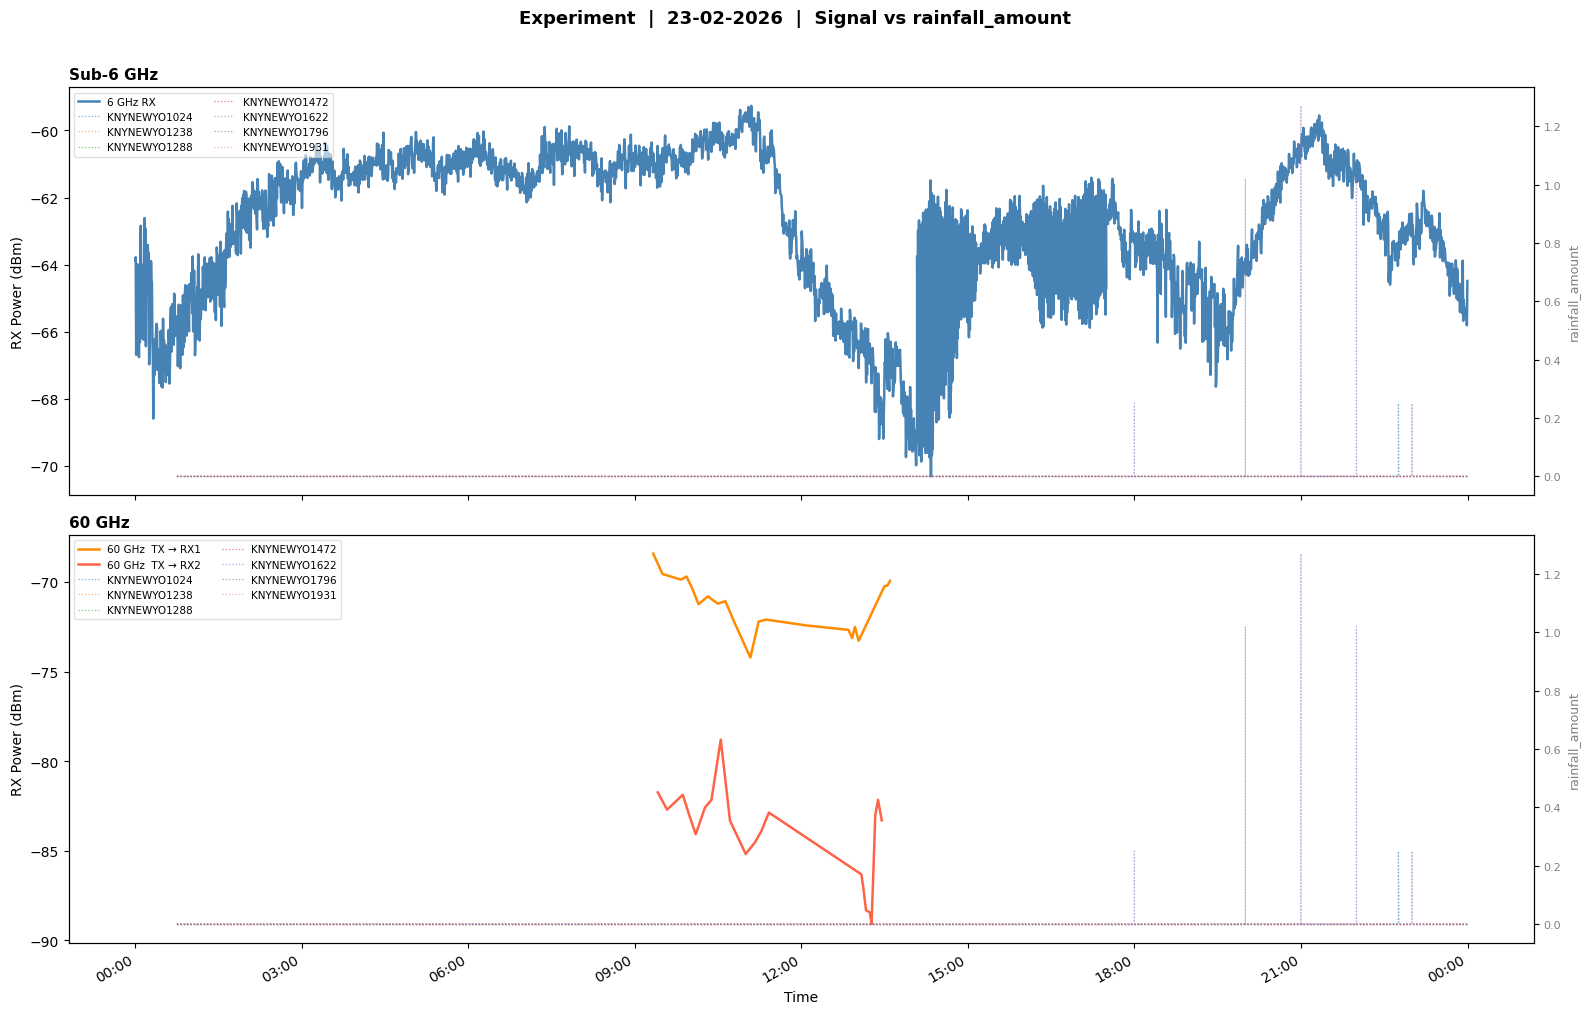

In [52]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

STATIONS = ['KNYNEWYO1024', 'KNYNEWYO1238', 'KNYNEWYO1288', 
            'KNYNEWYO1472', 'KNYNEWYO1622', 'KNYNEWYO1796', 'KNYNEWYO1931']

def plot_experiment(exp_analysis,
                    weather_var='rainfall_amount',
                    figsize=(16, 10)):

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    fig.suptitle(f"Experiment  |  23-02-2026  |  Signal vs {weather_var}", 
                 fontsize=13, fontweight='bold', y=1.01)

    rain_df = exp_analysis['pws'][weather_var]
    station_palette = plt.cm.tab10.colors

    # ── helper: add weather on twin axis ──────────────────────
    def add_weather(ax):
        ax2 = ax.twinx()
        for i, station in enumerate(STATIONS):
            s = rain_df[station].dropna()
            ax2.plot(s.index, s.values,
                     color=station_palette[i], linewidth=0.9,
                     linestyle=':', alpha=0.6, label=station)
        ax2.set_ylabel(weather_var, fontsize=9, color='gray')
        ax2.tick_params(axis='y', labelcolor='gray', labelsize=8)
        return ax2

    # ── PLOT 1 : Sub-6 GHz ────────────────────────────────────
    ax = axes[0]
    s = exp_analysis['experiment']['6ghz']
    ax.plot(s.index, s.values, color='steelblue', linewidth=1.8, label='6 GHz RX')
    ax.set_ylabel('RX Power (dBm)', fontsize=10)
    ax.set_title('Sub-6 GHz', fontsize=11, loc='left', fontweight='bold')
    ax2 = add_weather(ax)

    # combined legend
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=7.5,
              ncol=2, framealpha=0.6)

    # ── PLOT 2 : 60 GHz (TX → RX1 and TX → RX2) ──────────────
    ax = axes[1]
    ax.plot(exp_analysis['experiment']['60ghz_rx1'].index,
            exp_analysis['experiment']['60ghz_rx1'].values,
            color='darkorange', linewidth=1.8, label='60 GHz  TX → RX1')
    ax.plot(exp_analysis['experiment']['60ghz_rx2'].index,
            exp_analysis['experiment']['60ghz_rx2'].values,
            color='tomato', linewidth=1.8, label='60 GHz  TX → RX2')
    ax.set_ylabel('RX Power (dBm)', fontsize=10)
    ax.set_title('60 GHz', fontsize=11, loc='left', fontweight='bold')
    ax2 = add_weather(ax)

    # combined legend
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=7.5,
              ncol=2, framealpha=0.6)

    # ── X AXIS ────────────────────────────────────────────────
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
    axes[-1].set_xlabel('Time', fontsize=10)
    fig.autofmt_xdate()

    plt.tight_layout()
    plt.show()

# run
plot_experiment(exp_analysis)


In [39]:
# run this
print(exp_analysis['pws']['asos_stations'])
print(exp_analysis['pws']['asos_params'])

# peek at one asos param
asos_param = exp_analysis['pws']['asos_params'][0]
print(exp_analysis['pws'][asos_param].shape)
print(exp_analysis['pws'][asos_param].columns.tolist())

KeyError: 'asos_stations'

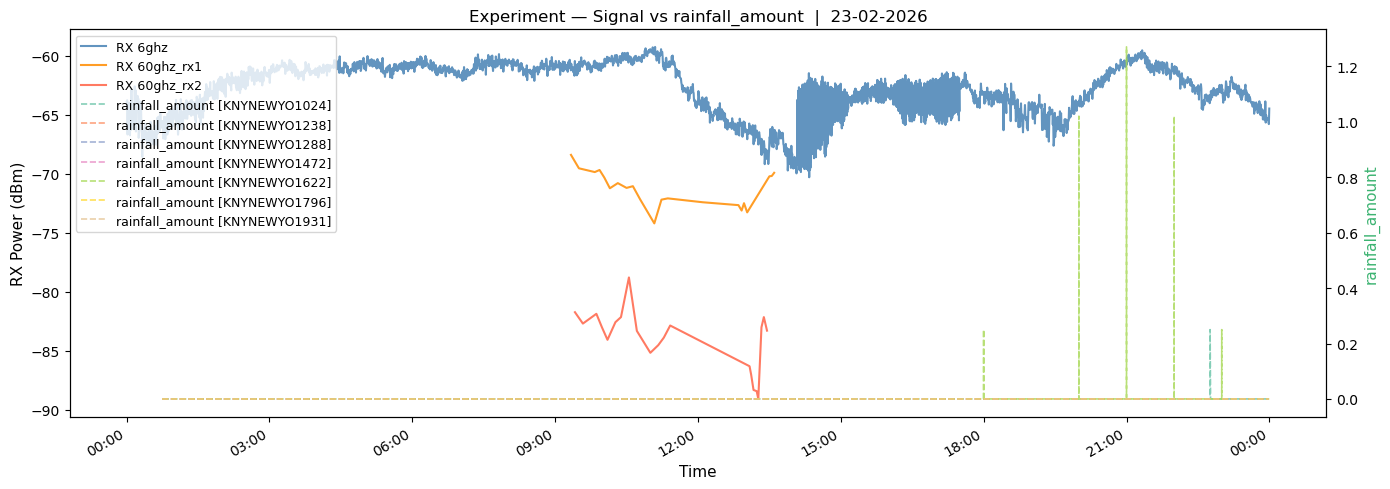

In [ ]:


# ── USAGE ─────────────────────────────────────────────────────


# pick specific stations
plot_experiment(exp_analysis, stations= list(exp_analysis['pws']['rainfall_amount']))


# pick specific stations
# plot_experiment(exp_analysis, stations=['KNYNEWYO1024', 'KNYNEWYO1472'])

# different weather var
# plot_experiment(exp_analysis, weather_var='humidity')

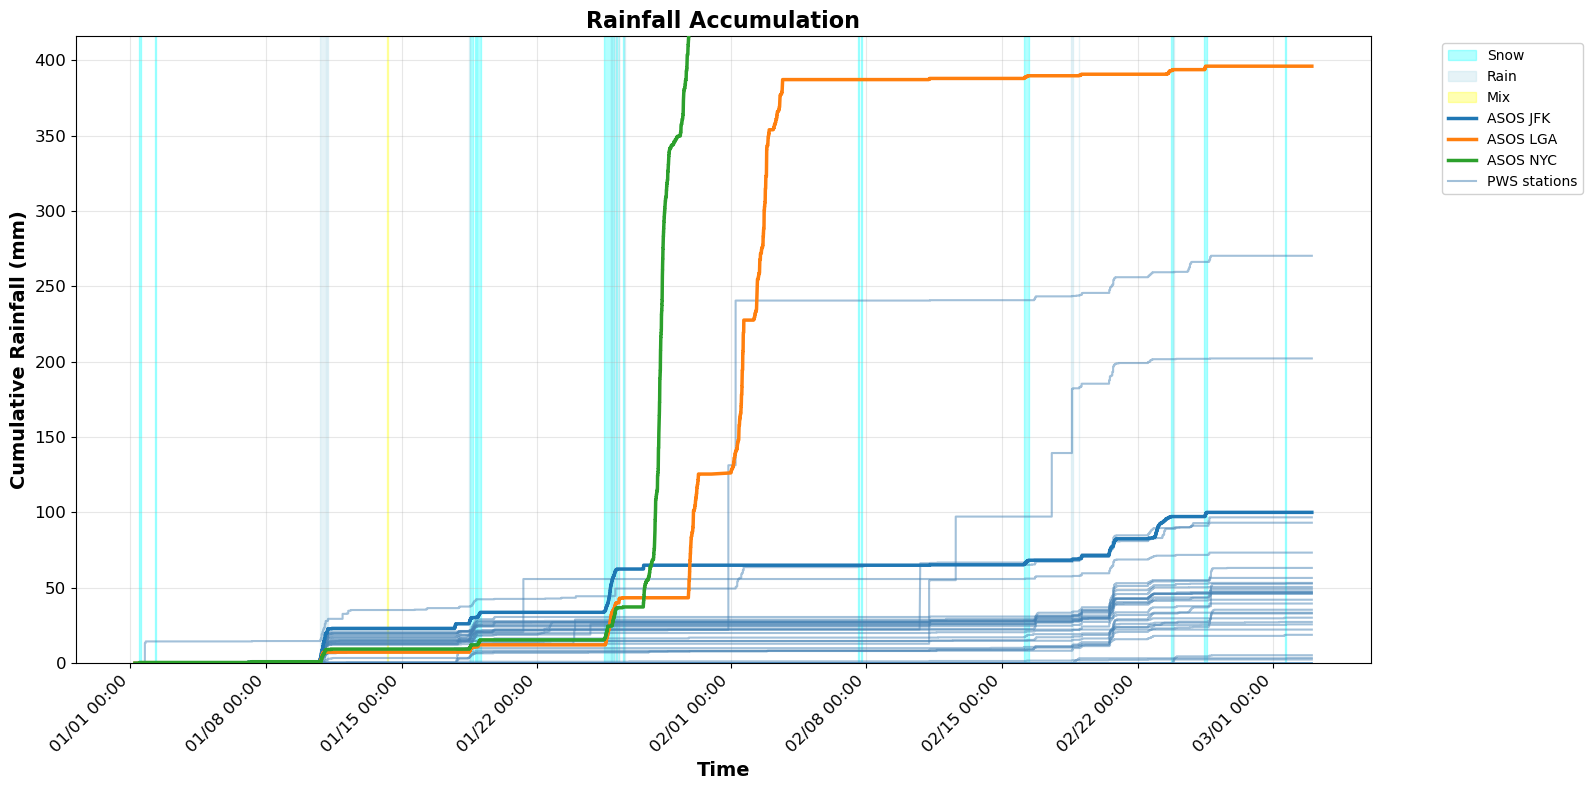

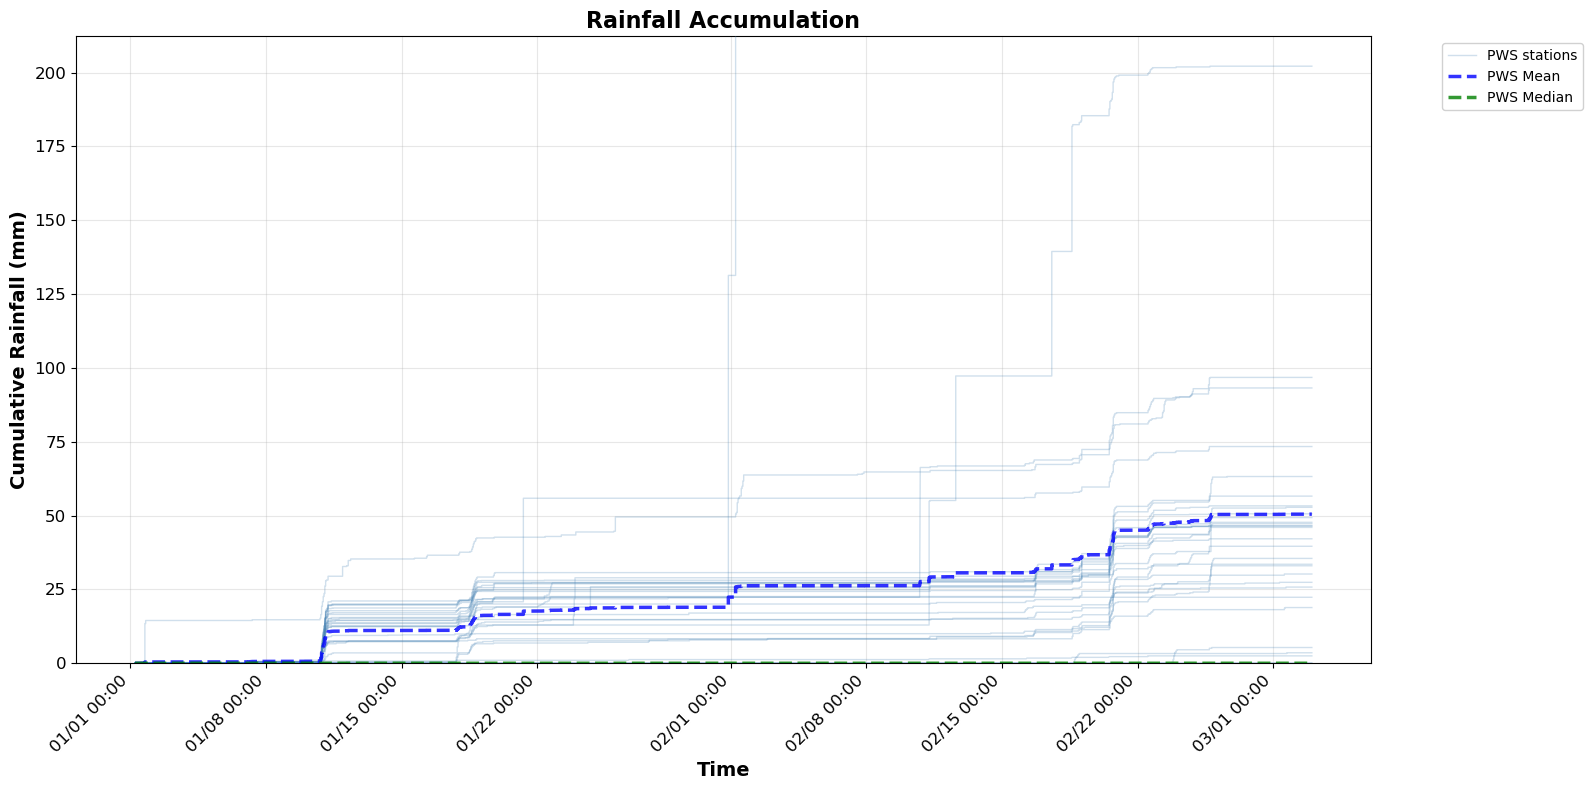

In [ ]:

fig, ax = accumulation_plot(
    analysis_data,
    date_range=(START_DATE, END_DATE),
    show_precip_grid=True
)


# PWS only with stats (individuals faded, mean/median visible)
fig, ax = accumulation_plot(
    analysis_data,
    date_range=(START_DATE, END_DATE),
    datasets='pws',
    stats=True
)

## 9. RSL Time Series

Plot Received Signal Level (RSL) time series for specific CML links to visualize signal attenuation patterns.

📅 Date range: 2024-01-15 00:00:00 to 2024-01-29 23:59:00
   Timesteps: 21600


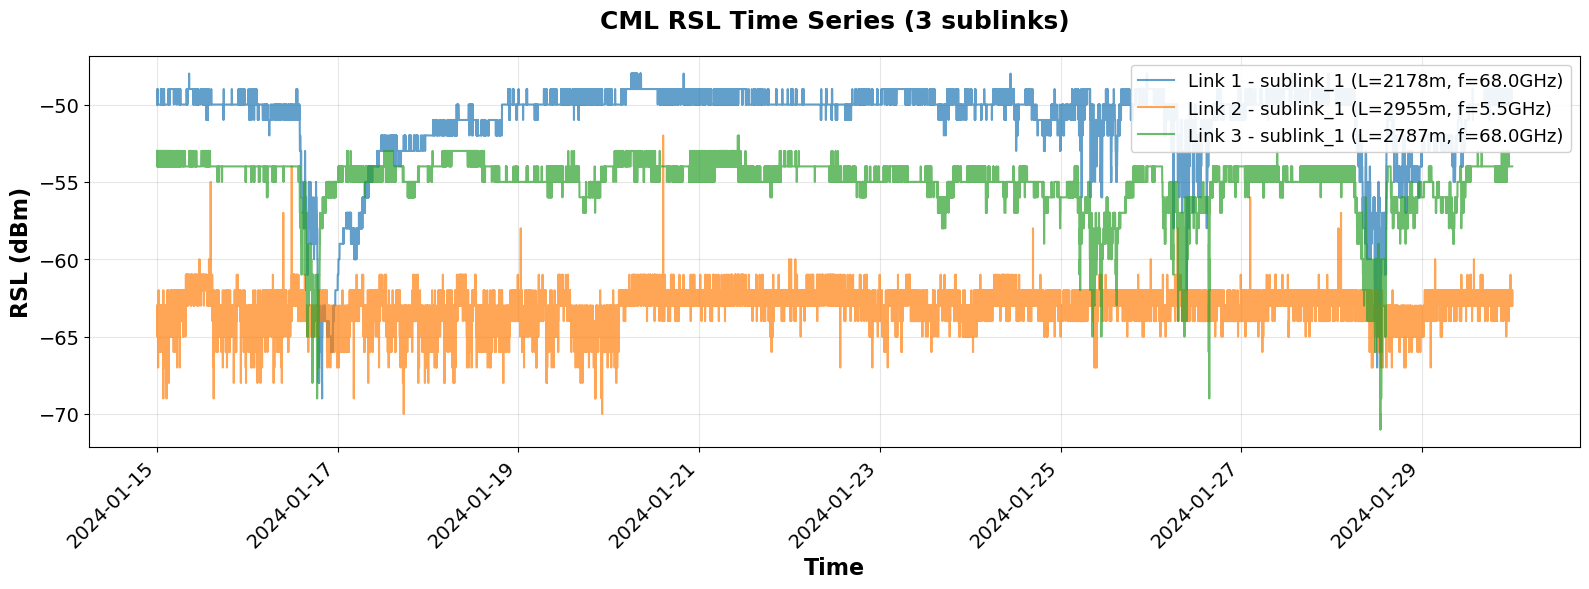

In [13]:
plot_cml_rsl(
    ds_links,
    cml_ids=['1', '2', '3'],
    sublink_ids='sublink_1',
    date_range=(START_DATE, END_DATE),
    figsize=(16, 6)
)

plt.show()

In [23]:
 # ds_links
 # metadata['openmesh_links']

## 10. Multipanel Plots with Matched Sensors

### 10.1. Match CML Links to PWS

In [ ]:
cml_to_pws, links_meta, pws_meta = find_nearest_pws_stations(
    ds_links=ds_links,
    links_meta=metadata['openmesh_links'],
    pws_meta=metadata['wu'],
    cml_ids= None,
    max_distance_km=5.0,
    max_stations=None,
)


ℹ No CML IDs specified - processing all 75 links in dataset

Sample link→PWS matches:
  Link 1: 10 PWS within 5.0km
  Link 2: 10 PWS within 5.0km
  ... and 73 more links

✓ Filtered network: 103 links, 36 PWS stations


In [ ]:
cml_to_pws_network, links_filtered, pws_filtered = find_nearest_pws_stations(
    ds_links=ds_links,
    links_meta=links_meta,
    pws_meta=metadata['wu'],
    cml_ids=None,
    max_distance_km=5.0,
    max_stations=None,
)
filtered_links = filter_cml_links(
    df_metadata=links_meta,
    freq_range=(5000, 7000),
    length_range=(3000, 8000),
)
cml_ids_from_meta = list(filtered_links.index)
available_cml_ids = [str(cid) for cid in ds_links.cml_id.values]
cml_ids = [cid for cid in cml_ids_from_meta if str(cid) in available_cml_ids]

cml_to_pws_network, links_filtered, pws_filtered = find_nearest_pws_stations(
    ds_links=ds_links,
    links_meta=links_meta,
    pws_meta=metadata['wu'],
    cml_ids=cml_ids,
    max_distance_km=5.0,
    max_stations=None,
)


ℹ No CML IDs specified - processing all 75 links in dataset

Sample link→PWS matches:
  Link 1: 10 PWS within 5.0km
  Link 2: 10 PWS within 5.0km
  ... and 73 more links

✓ Filtered network: 103 links, 36 PWS stations

Sample link→PWS matches:
  Link 19: 11 PWS within 5.0km
  Link 20: 12 PWS within 5.0km
  ... and 2 more links

✓ Filtered network: 7 links, 21 PWS stations


✓ Matplotlib map created


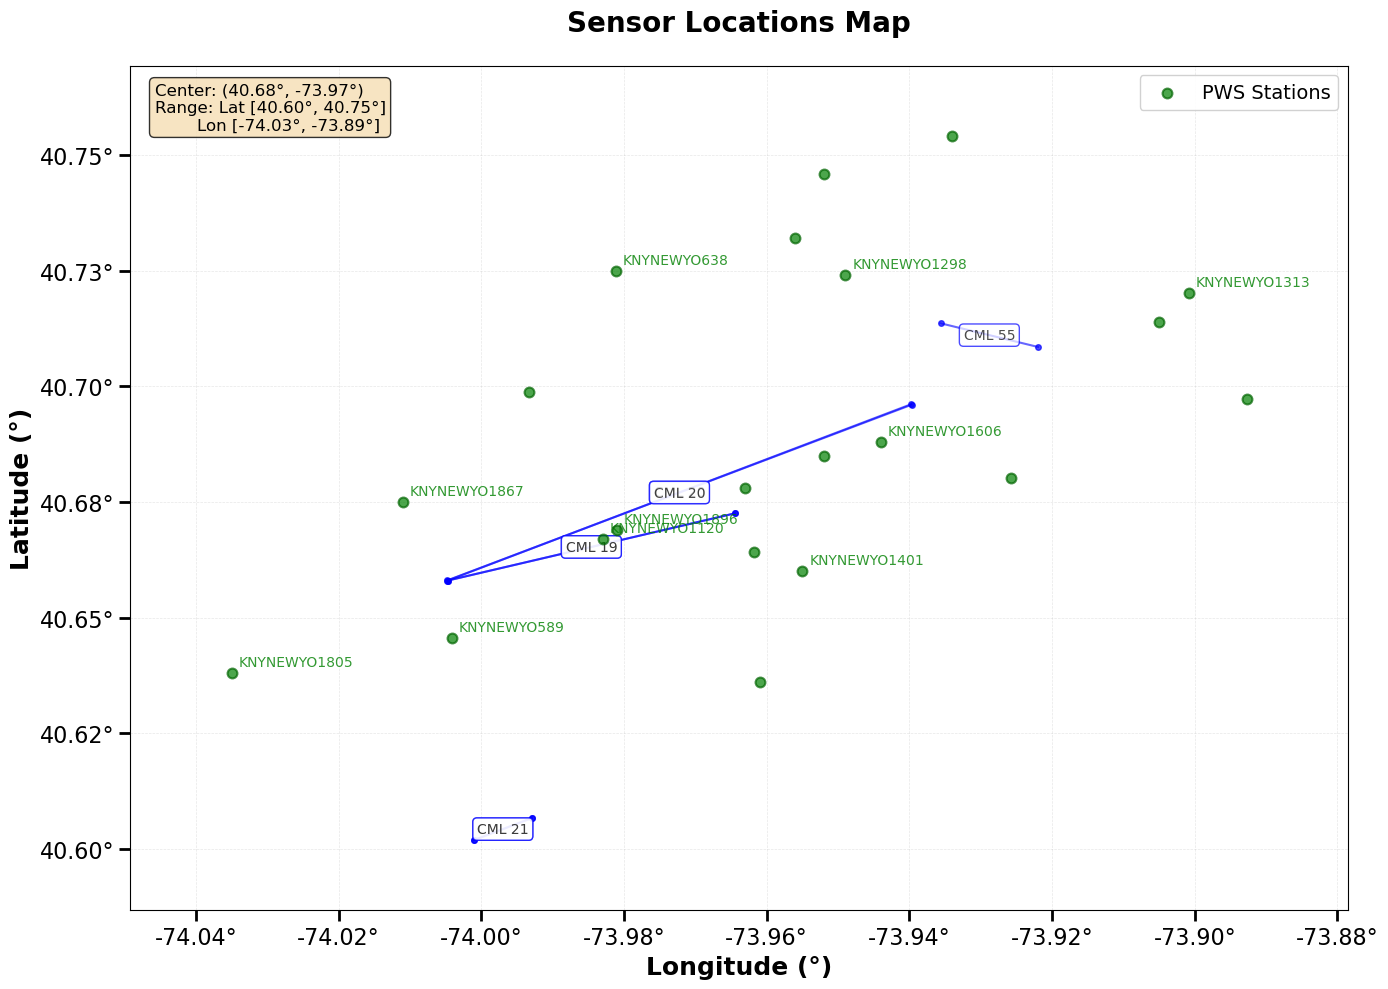

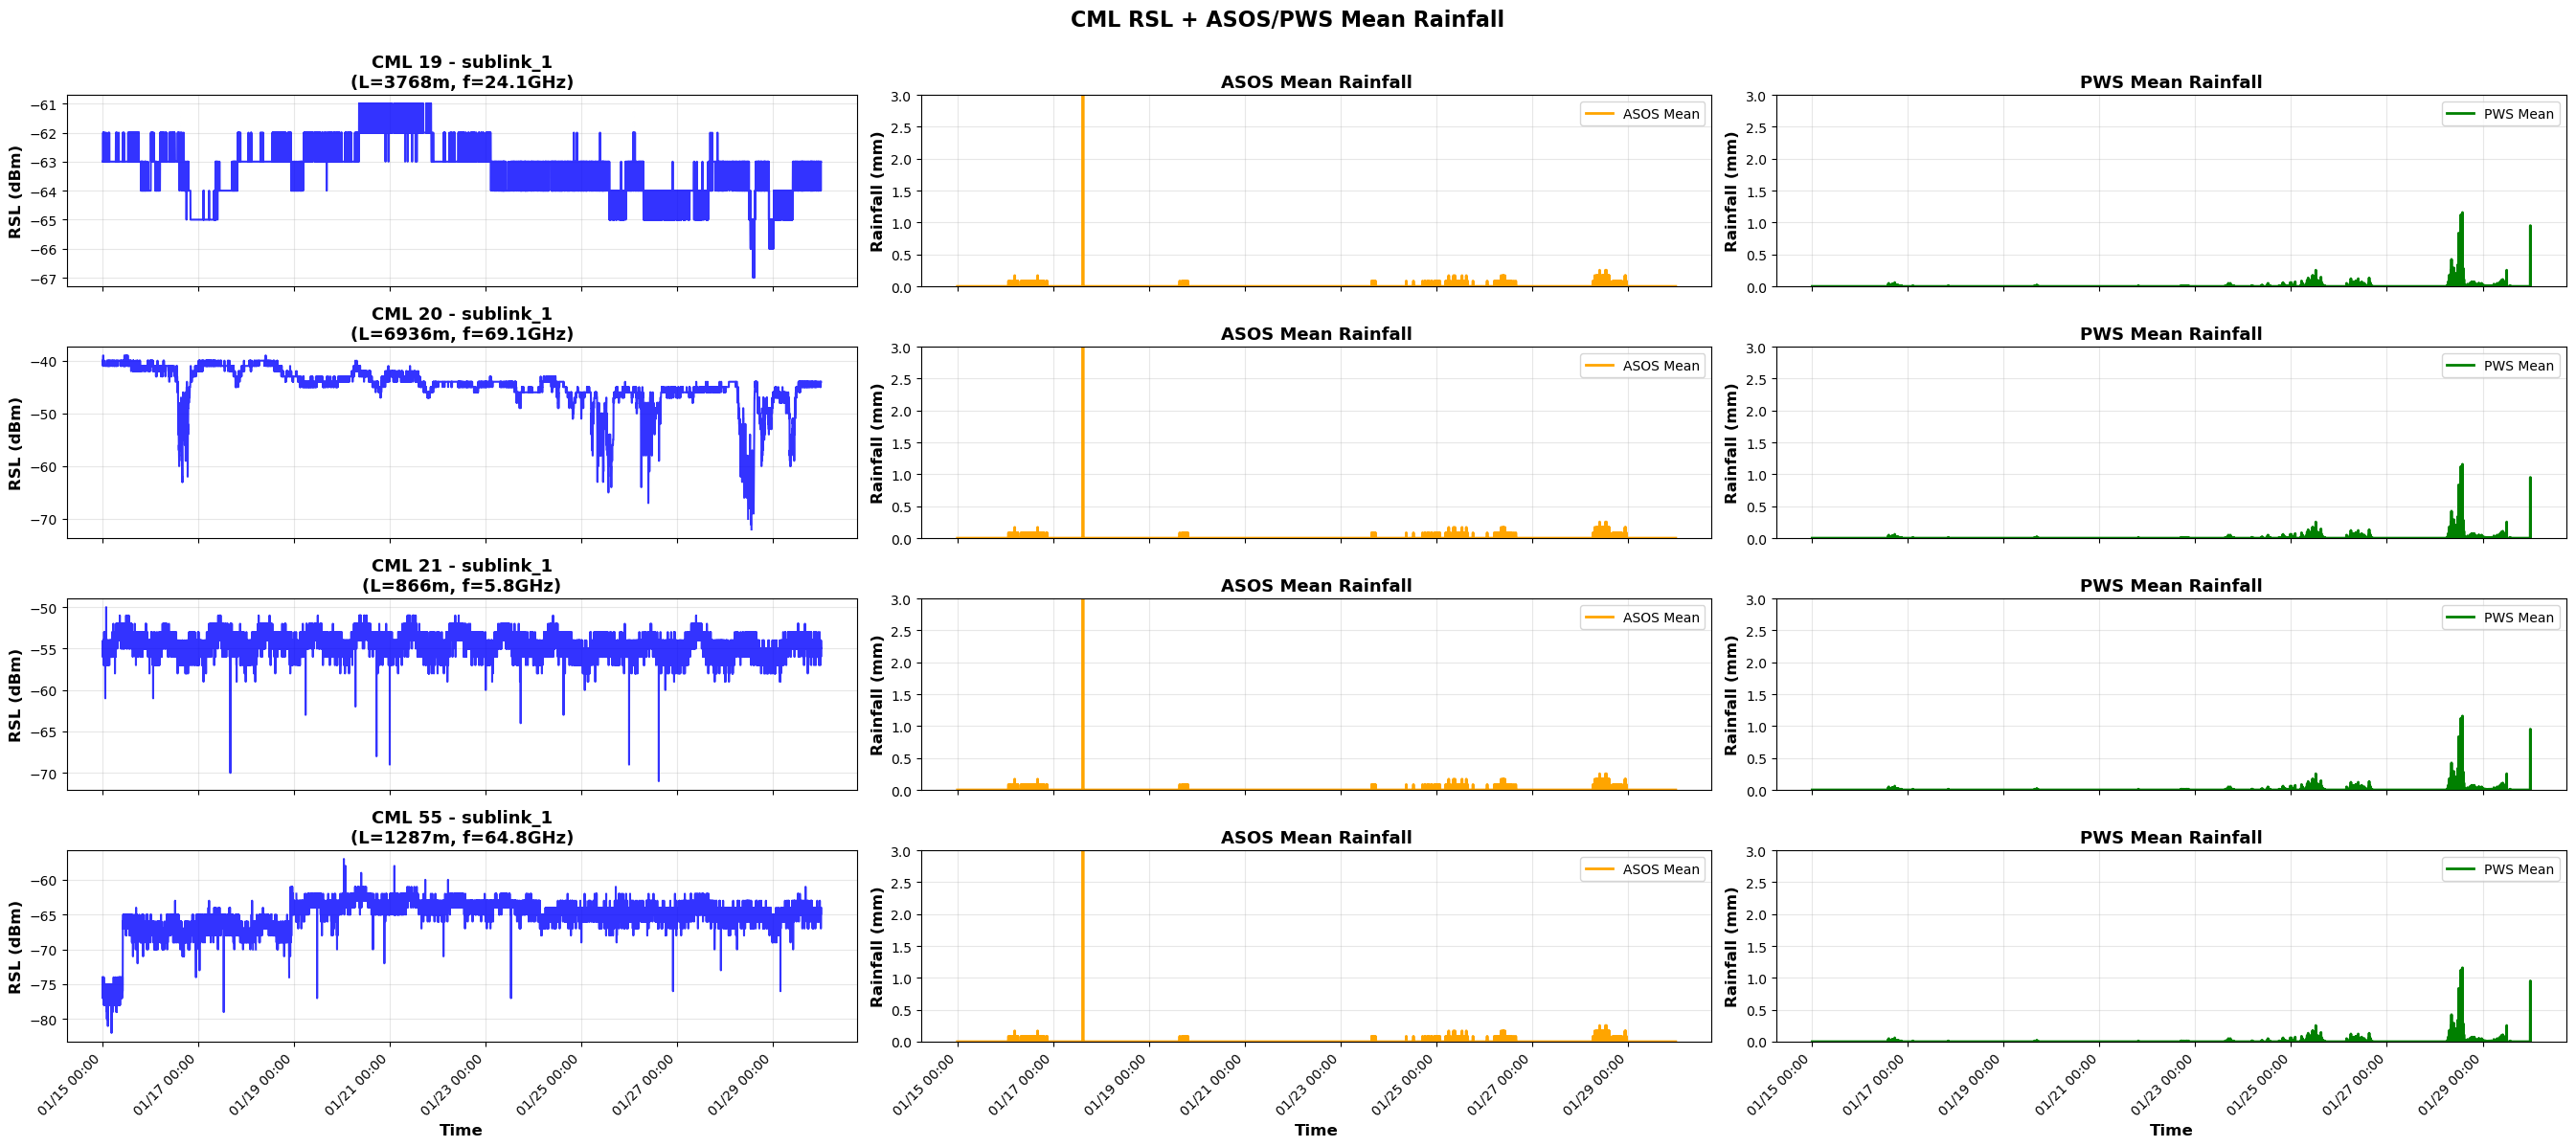

In [ ]:
display_sensors_map(
    links_meta=links_filtered,
    pws_meta=pws_filtered,
    asos_meta=None,
    show_link_labels=True,
    map_type='matplotlib',
)
fig, axes = plot_subnetwork(
    ds_links=ds_links,
    analysis_data=analysis_data,
    cml_to_pws=cml_to_pws_network,
    sublink_id='sublink_1',
    date_range=(START_DATE, END_DATE),
    figsize=(18, 12),
    y_lim=[0, 3],
)
plt.show()

### 10.2. Stacked Layout

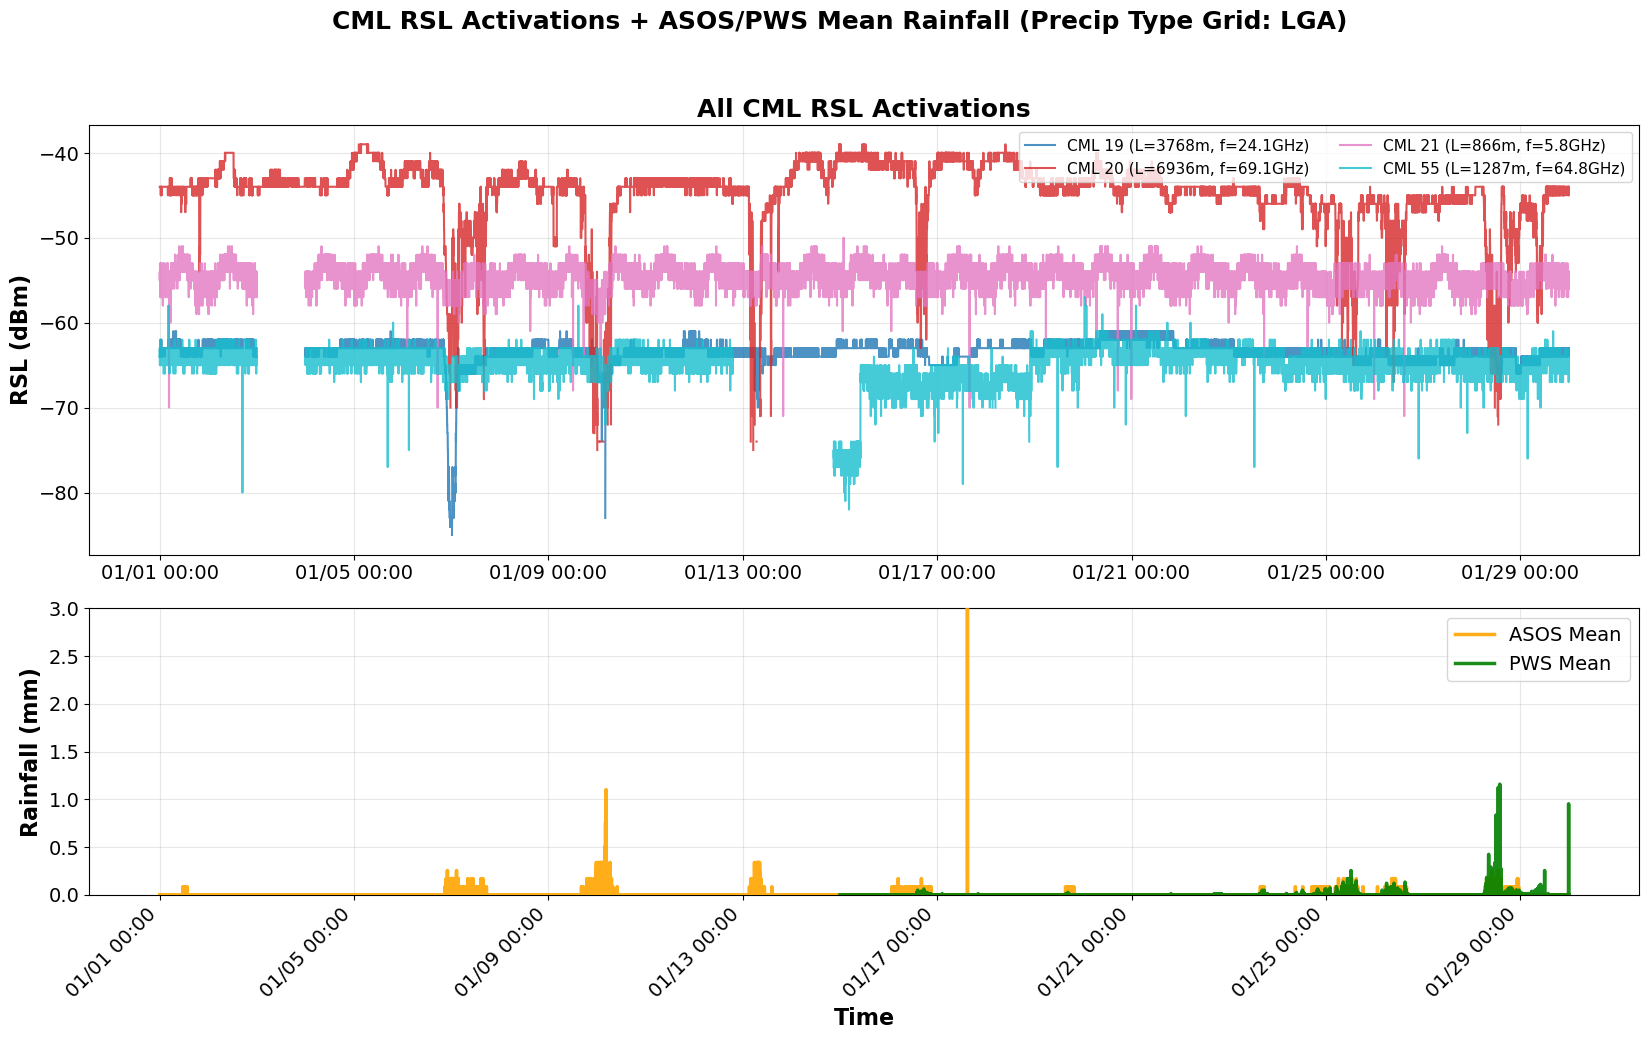

In [ ]:
fig, axes = plot_subnetwork(ds_links, analysis_data, cml_to_pws_network,
                           date_range=(START_DATE, END_DATE), plot_type='LGA',
                           layout='vertical', rainfall_source='both')

## 11. Rain Detection (Rolling STD)

CML RSL → rolling std detection; validate against PWS + ASOS rainfall.


✓ Detection: 406 periods (14.6%) | threshold=1.0 dB


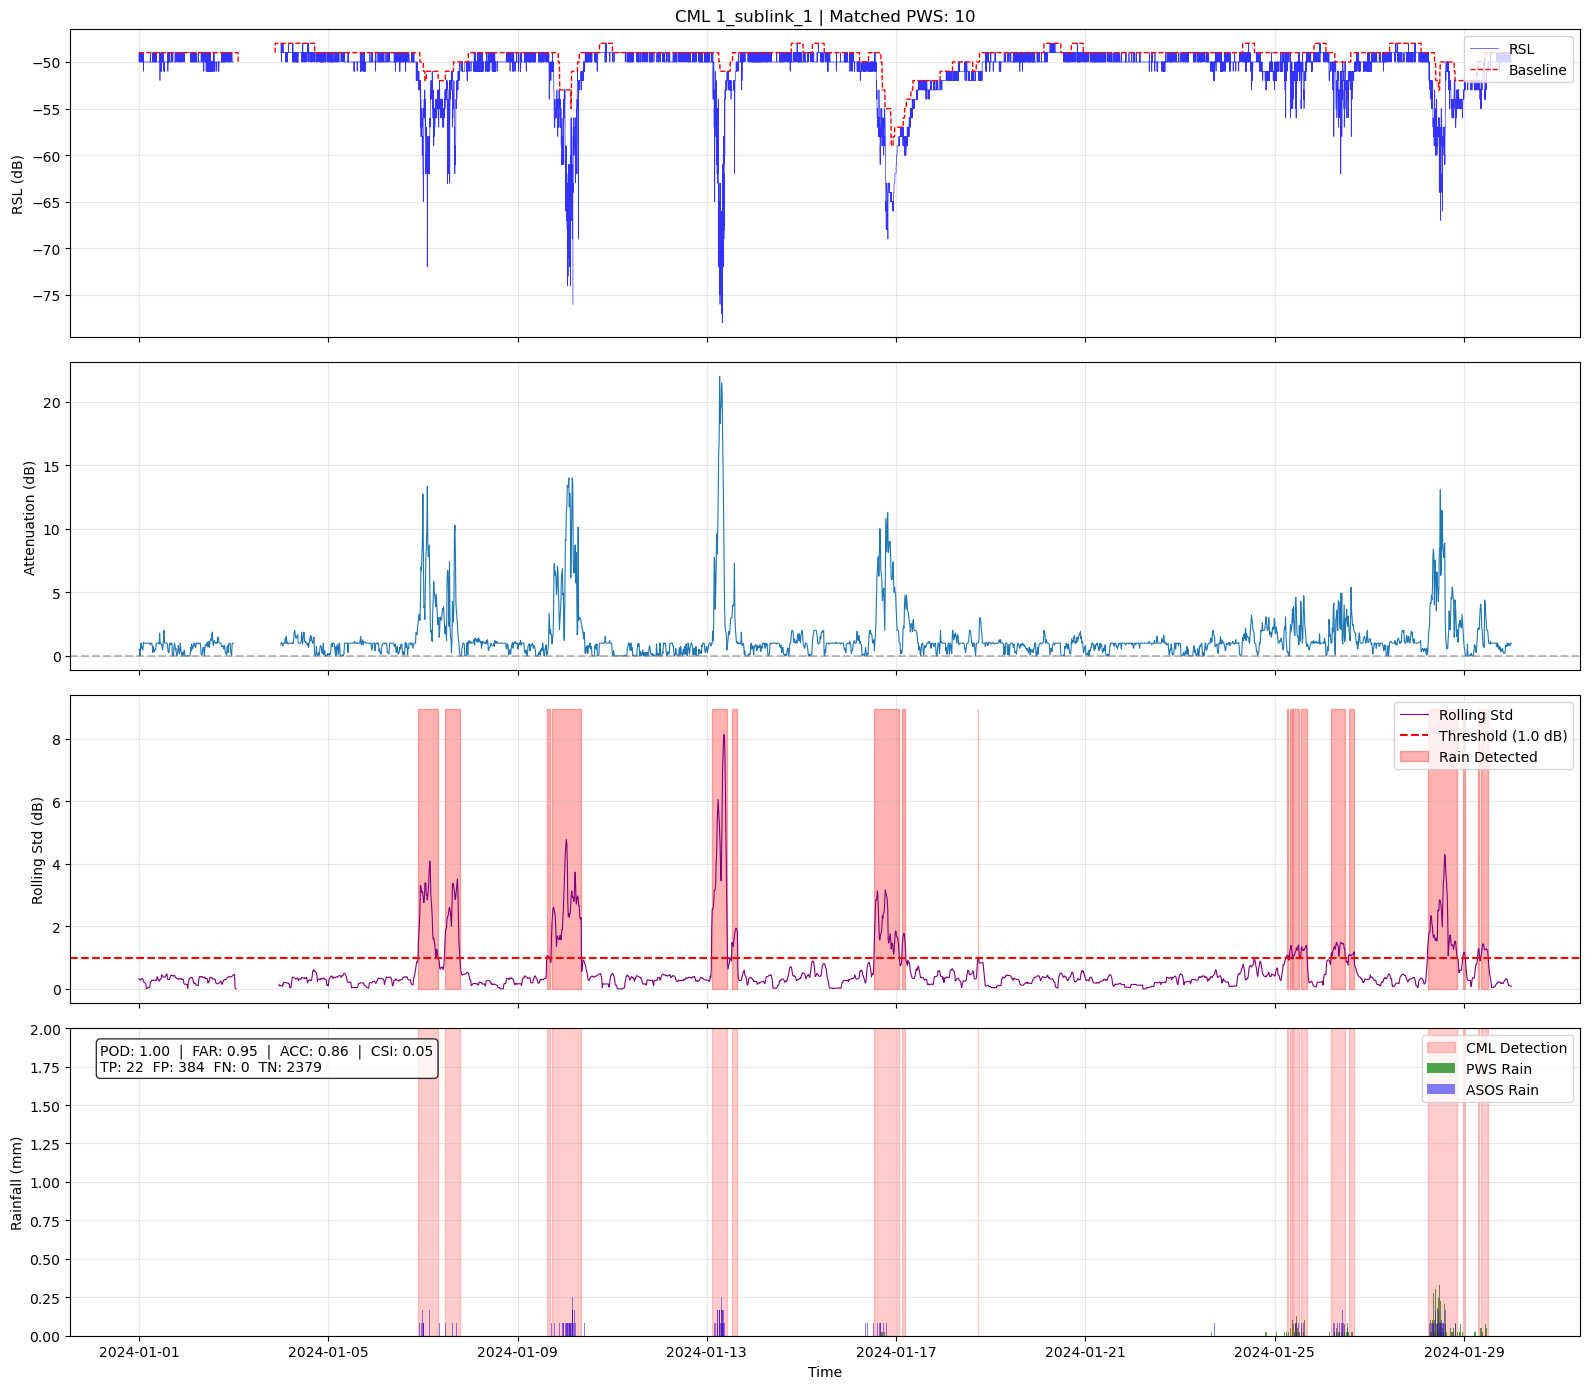


DETECTION METRICS
  POD (Hit Rate):     100.00%
  FAR (False Alarm):  94.58%
  Accuracy:           86.21%
  CSI (Threat Score): 5.42%


In [ ]:
START_DATE = datetime(2024, 1, 1)
END_DATE = datetime(2024, 1, 30)
CML_ID = '1'
SUBLINK_ID = 'sublink_1'
BASELINE_WINDOW = '6h'
BASELINE_METHOD = 'max'
DETECTION_WINDOW = '3h'
THRESHOLD = 1.0
RESAMPLE = '15min'
RAIN_Y_MAX = 2.0
SHOW_METRICS = True

df_cml, df_pws_rain, df_asos_rain, matched_pws = prepare_detection_data(
    analysis_data, CML_ID, SUBLINK_ID, cml_to_pws,
    baseline_window=BASELINE_WINDOW,
    baseline_method=BASELINE_METHOD
)

df_detection = run_rolling_std_detection(
    df_cml, window=DETECTION_WINDOW, threshold=THRESHOLD, resample=RESAMPLE
)

plot_detection_results(
    df_cml, df_detection, df_pws_rain, df_asos_rain,
    title=f'CML {CML_ID}_{SUBLINK_ID} | Matched PWS: {len(matched_pws)}',
    start_date=START_DATE,
    end_date=END_DATE,
    rain_y_max=RAIN_Y_MAX,
    show_metrics=SHOW_METRICS
)

---
## Done
